# Computer_Exercise_AG#1

---
**Disclosures**

AI Assistance: GitHub Copilot was used to support debugging and to clarify usage of certain OpenCV, scikit-image, and ipywidgets APIs. All generated suggestions were carefully reviewed and modified where necessary. I take full responsibility for the final implementation.

Images: All images used for testing and demonstration were sourced from Pixabay under the Pixabay Content License, which permits free use for educational and non-commercial purposes. No copyright-protected material was used without permission.

  **Note:** 
> This notebook contains interactive widgets powered by `ipywidgets`.
> For the best experience, open this notebook in **Jupyter Notebook** or **JupyterLab** using a **Chrome** browser.
> The interactive widgets may not render correctly in VS Code's built-in notebook viewer.

---


# Starter Notebook: Old Photo Restoration

This notebook supports two workflows:

1. **Real old photo**: place your image at `old_photo_input.jpg` (or change `IMG_PATH`).
2. **Synthetic degradation** (recommended for quantitative evaluation): start from a clean image (or the fallback synthetic base), add dust/scratches/fading, then restore and compare.

You will implement:
- DFT analysis
- Gaussian smoothing
- derivatives/gradients
- median filtering
- morphology (opening/closing, morphological gradient)
- optional inpainting + contrast enhancement

Figures are saved to `figs/` for your report.


In [6]:
%%capture
!! pip install ipywidgets
!! pip install widgetsnbextension
!! pip install numpy
!! pip install opencv-python
!! pip install matplotlib
!! pip install scikit-image
!! pip install ipython

In [217]:
import os
from pathlib import Path
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

Path("photos").mkdir(exist_ok=True)
plt.rcParams["figure.dpi"] = 120
Path("figs").mkdir(exist_ok=True)

def show(img, title="", cmap="gray"):
    plt.figure()
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

def save_u8(path, img):
    if img.dtype != np.uint8:
        img2 = cv.normalize(img, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
    else:
        img2 = img
    cv.imwrite(path, img2)
    print("Saved", path)


Load a image (real photo if available; otherwise fallback synthetic)

Loaded fallback synthetic base image (old_photo_input.jpg not found).


[ WARN:0@26294.169] global loadsave.cpp:244 findDecoder imread_('../photos/old_photo_22.jpg'): can't open/read file: check file path/integrity


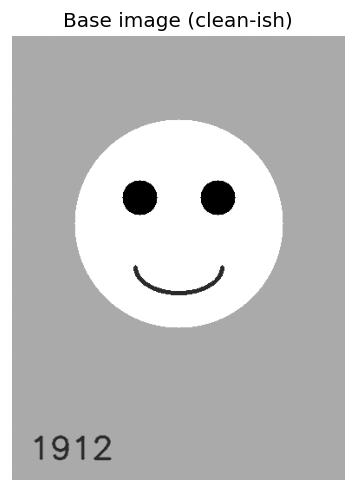

Saved figs/clean_base.png


In [218]:

IMG_PATH = "../photos/old_photo_22.jpg"  # change as needed
#IMG_PATH = "../62-216.jpg"  # change as needed

img_bgr = cv.imread(IMG_PATH, cv.IMREAD_COLOR)

if img_bgr is None:
    # Fallback: simple synthetic base (so the lab always runs)
    h, w = 512, 384
    img = np.full((h, w), 120, dtype=np.uint8)
    cv.circle(img, (w//2, h//2-40), 120, 140, -1)                # face
    cv.circle(img, (w//2-45, h//2-70), 20, 80, -1)               # left eye
    cv.circle(img, (w//2+45, h//2-70), 20, 80, -1)               # right eye
    cv.ellipse(img, (w//2, h//2+10), (50, 30), 0, 0, 180, 90, 4) # smile
    cv.putText(img, "1912", (20, h-25), cv.FONT_HERSHEY_SIMPLEX, 1.2, 90, 2, cv.LINE_AA)
    img_gray_clean = img
    print("Loaded fallback synthetic base image (old_photo_input.jpg not found).")
else:
    img_gray_clean = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)
    print("Loaded:", IMG_PATH)

gt = img_gray_clean           #Ground Truth Image
show(img_gray_clean, "Base image (clean-ish)")
save_u8("figs/clean_base.png", img_gray_clean)


## Create synthetic degradation (dust, scratches, fading, grain)

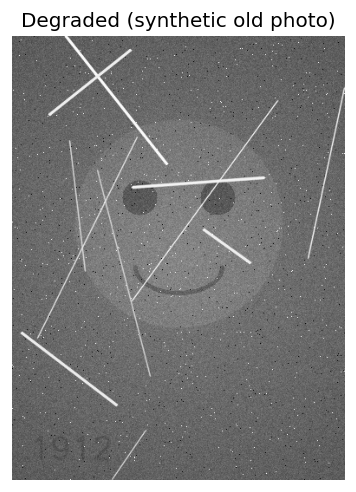

Saved figs/degraded.png


In [219]:

rng = np.random.default_rng(0)

def add_fading(img, strength=0.35):
    imgf = img.astype(np.float32)
    imgf = imgf * (1.0 - strength) + 128 * strength
    h, w = img.shape
    yy, xx = np.mgrid[0:h, 0:w]
    cy, cx = h/2, w/2
    r = np.sqrt((yy-cy)**2 + (xx-cx)**2) / np.sqrt(cy**2 + cx**2)
    vign = 1.0 - 0.25 * r
    imgf = imgf * vign
    return np.clip(imgf, 0, 255).astype(np.uint8)

def add_dust(img, p=0.006):
    out = img.copy()
    mask = rng.random(img.shape) < p
    out[mask] = rng.choice([0, 255], size=mask.sum()).astype(np.uint8)
    return out

def add_scratches(img, n_lines=16):
    out = img.copy()
    h, w = img.shape
    for _ in range(n_lines):
        x1 = int(rng.integers(0, w))
        y1 = int(rng.integers(0, h))
        x2 = int(np.clip(x1 + rng.integers(-w//2, w//2), 0, w-1))
        y2 = int(np.clip(y1 + rng.integers(-h//2, h//2), 0, h-1))
        thickness = int(rng.integers(1, 3))
        color = int(rng.integers(210, 255))  # bright scratch
        cv.line(out, (x1, y1), (x2, y2), color, thickness, cv.LINE_AA)
    return out

def add_grain(img, sigma=9.0):
    n = rng.normal(0, sigma, img.shape).astype(np.float32)
    out = np.clip(img.astype(np.float32) + n, 0, 255).astype(np.uint8)
    return out

img_deg = img_gray_clean.copy()
img_deg = add_fading(img_deg, strength=0.35)
img_deg = add_grain(img_deg, sigma=9.0)
img_deg = add_dust(img_deg, p=0.006)
img_deg = add_scratches(img_deg, n_lines=11)

show(img_deg, "Degraded (synthetic old photo)")
save_u8("figs/degraded.png", img_deg)


### DFT magnitude

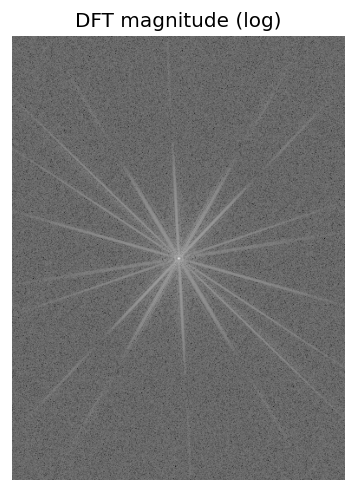

Saved figs/dft_magnitude.png


In [220]:
#img_deg = img_gray_clean
F = np.fft.fft2(img_deg)
Fshift = np.fft.fftshift(F)
mag = np.log(np.abs(Fshift) + 1.0)
mag_u8 = (255 * (mag - mag.min()) / (mag.max() - mag.min() + 1e-12)).astype(np.uint8)

show(mag_u8, "DFT magnitude (log)")
save_u8("figs/dft_magnitude.png", mag_u8)


## Gaussian smoothing (choose $\sigma$ or a range of $\sigma$ values)

#### Note:  You need to pick one value for `sigma_choice` that will be used in later steps.

/var/folders/2k/qw56vf3j1tv_5nr2s834fm8c0000gn/T/ipykernel_43915/3400578722.py:8: UserWarning: Glyph 65023 (\N{ARABIC LIGATURE AZZA WA JALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()


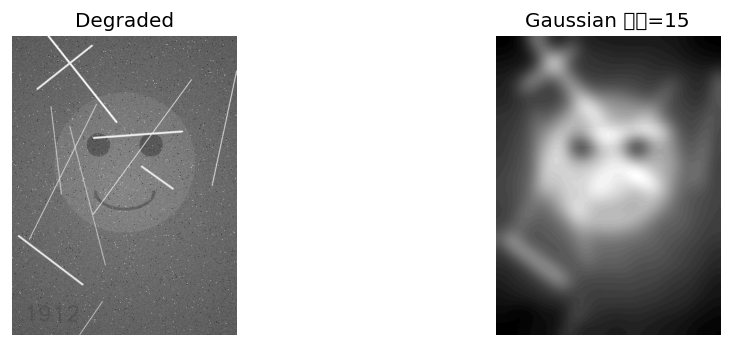

Saved figs/gaussian_example.png


In [221]:

sigmas = [15]   # Put in your value(s) for sigma here - can be a list.
blurs = [cv.GaussianBlur(img_deg, (0,0), s, s) for s in sigmas]

plt.figure(figsize=(10,3))
plt.subplot(1, len(sigmas)+1, 1); plt.imshow(img_deg, cmap="gray"); plt.title("Degraded"); plt.axis("off")
for i, s in enumerate(sigmas):
    plt.subplot(1, len(sigmas)+1, i+2); plt.imshow(blurs[i], cmap="gray"); plt.title(f"Gaussian ﷿﷿={s}"); plt.axis("off")
plt.tight_layout(); plt.show()

save_u8("figs/gaussian_example.png", np.hstack([blurs[0], blurs[-1]]))

# Pick one sigma for later steps
sigma_choice = 15
img_s = cv.GaussianBlur(img_deg, (0,0), sigma_choice, sigma_choice)


## Gradients (Sobel)

The code below finds the gradient vector using a Sobel filter.  The default value for the kernel size is `ksize=3`.  The commonly used values are `k=1,3,5,7` with `k=-1` producing a Scharr filter.

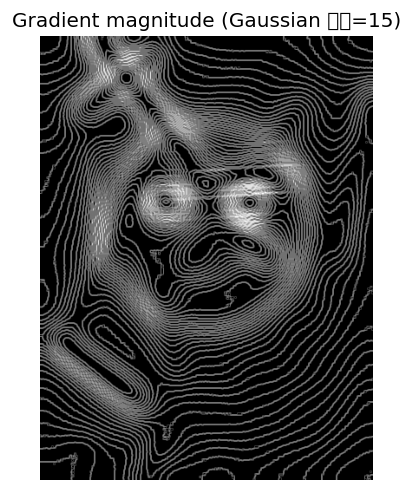

Saved figs/gradient_example.png


In [222]:
ksize = 3        #Pick the kernel size - the defaul is 3
gx = cv.Sobel(img_s, cv.CV_64F, 1, 0, ksize=ksize)      
gy = cv.Sobel(img_s, cv.CV_64F, 0, 1, ksize=ksize)
gmag = np.sqrt(gx*gx + gy*gy)
gmag_u8 = cv.normalize(gmag, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

show(gmag_u8, f"Gradient magnitude (Gaussian ﷿﷿={sigma_choice})")
save_u8("figs/gradient_example.png", gmag_u8)


## Median filtering (dust)

In OpenCV, the median filter size `k` must be specified.  The filter size must be odd and greater than 3.  The most common values for `k` are 3,5,7.

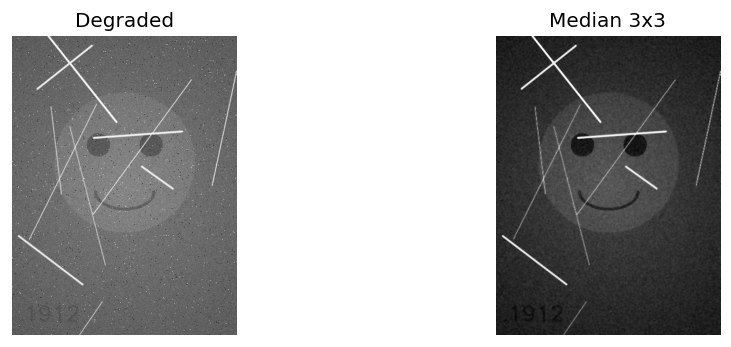

Saved figs/median_example.png


In [223]:
ksize= 3            #Pick the size of the median filter
med5 = cv.medianBlur(img_deg, ksize=ksize)

plt.figure(figsize=(10,3))
plt.subplot(1,2,1); plt.imshow(img_deg, cmap="gray"); plt.title("Degraded"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(med5, cmap="gray"); plt.title(f"Median {ksize}x{ksize}"); plt.axis("off")
plt.tight_layout(); plt.show()

save_u8("figs/median_example.png", np.hstack([img_deg, med5]))


## Morphology (Mask Refinement + Morph Gradient)

Here, the input is the gradient magnitude image. Read the write-up for other options for the input as well as the structuring element that is used.

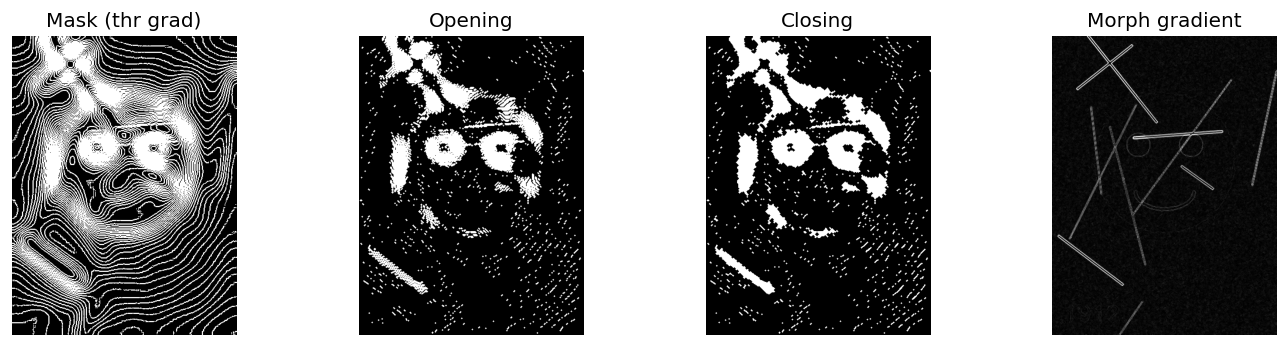

Saved figs/morph_example.png


In [224]:

thr = int(0.35 * gmag_u8.max())                               # Pick your threshold
_, mask = cv.threshold(gmag_u8, thr, 255, cv.THRESH_BINARY)   # Gradient magnitued

kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3,3))    #Define your structuring element and size
mask_open = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel, iterations=1)
mask_close = cv.morphologyEx(mask_open, cv.MORPH_CLOSE, kernel, iterations=2)

# Morph gradient on median-filtered image
dil = cv.dilate(med5, kernel, iterations=1)
ero = cv.erode(med5, kernel, iterations=1)
mgrad = cv.subtract(dil, ero)

plt.figure(figsize=(12,3))
plt.subplot(1,4,1); plt.imshow(mask, cmap="gray"); plt.title("Mask (thr grad)"); plt.axis("off")
plt.subplot(1,4,2); plt.imshow(mask_open, cmap="gray"); plt.title("Opening"); plt.axis("off")
plt.subplot(1,4,3); plt.imshow(mask_close, cmap="gray"); plt.title("Closing"); plt.axis("off")
plt.subplot(1,4,4); plt.imshow(mgrad, cmap="gray"); plt.title("Morph gradient"); plt.axis("off")
plt.tight_layout(); plt.show()

save_u8("figs/morph_example.png", np.hstack([mask, mask_close, mgrad]))


## Optional inpainting + CLAHE (final output)

***Note***:  You probably want to experiment with the inpaint radius, along with the CLAHE hyperparameters.

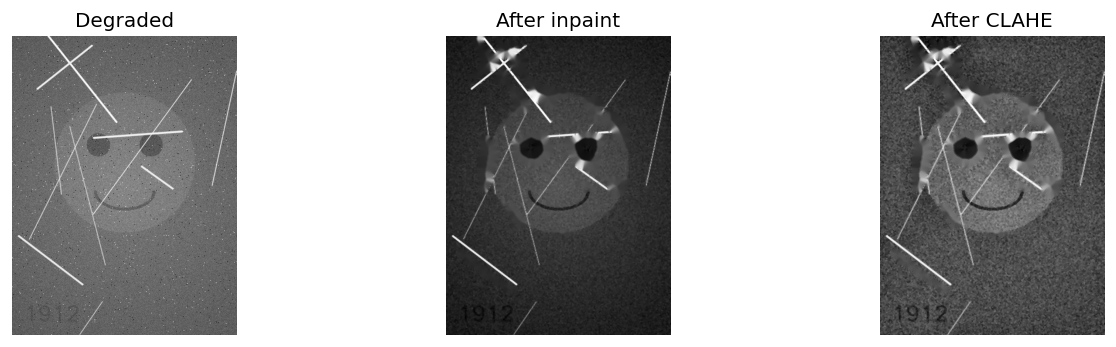

Saved figs/final_restored.png


In [225]:

inpaint_radius = 3
rest_inpaint = cv.inpaint(med5, mask_close, inpaint_radius, cv.INPAINT_TELEA)

clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
rest_final = clahe.apply(rest_inpaint)

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); plt.imshow(img_deg, cmap="gray"); plt.title("Degraded"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(rest_inpaint, cmap="gray"); plt.title("After inpaint"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(rest_final, cmap="gray"); plt.title("After CLAHE"); plt.axis("off")
plt.tight_layout(); plt.show()

save_u8("figs/final_restored.png", rest_final)


## Quantitative evaluation (synthetic ground truth)

### PSNR

In [226]:
def psnr(a, b):
    a = a.astype(np.float32)
    b = b.astype(np.float32)
    mse = np.mean((a-b)**2)
    if mse == 0:
        return float("inf")
    return 10*np.log10((255**2)/mse)

print("PSNR(degraded vs clean):", psnr(img_deg, img_gray_clean))
print("PSNR(restored vs clean):", psnr(rest_final, img_gray_clean))


PSNR(degraded vs clean): 19.974586387053773
PSNR(restored vs clean): 20.659217020509395


### Grain Proxy

In [227]:
img_in = img_deg
img_out = rest_final
gt = img_gray_clean
def grain_proxy_std(img_u8, sigma=2.0):
    x = img_u8.astype(np.float32) / 255.0
    low = cv.GaussianBlur(x, (0,0), sigmaX=sigma, sigmaY=sigma)
    r = x - low
    return float(r.std()), r  # std in [0..1] scale

g_in, r_in = grain_proxy_std(img_in, sigma=2.0)
g_out, r_out = grain_proxy_std(img_out, sigma=2.0)
print("Grain proxy std (in,out):", g_in, g_out)

Grain proxy std (in,out): 0.06347699463367462 0.042849909514188766


### Edge Density

In [228]:
def edge_density_canny(img_u8, t1=50, t2=150, blur=1.0):
    x = img_u8
    if blur and blur > 0:
        x = cv.GaussianBlur(x, (0,0), blur)
    e = cv.Canny(x, t1, t2)
    dens = float((e > 0).mean())
    return dens, e

d_in, e_in = edge_density_canny(img_in)
d_out, e_out = edge_density_canny(img_out)
print("Edge density (in,out):", d_in, d_out)

Edge density (in,out): 0.026590983072916668 0.028401692708333332


### Structural Similarity Indes (SSIM)

SSIM: 0.41166874384220675


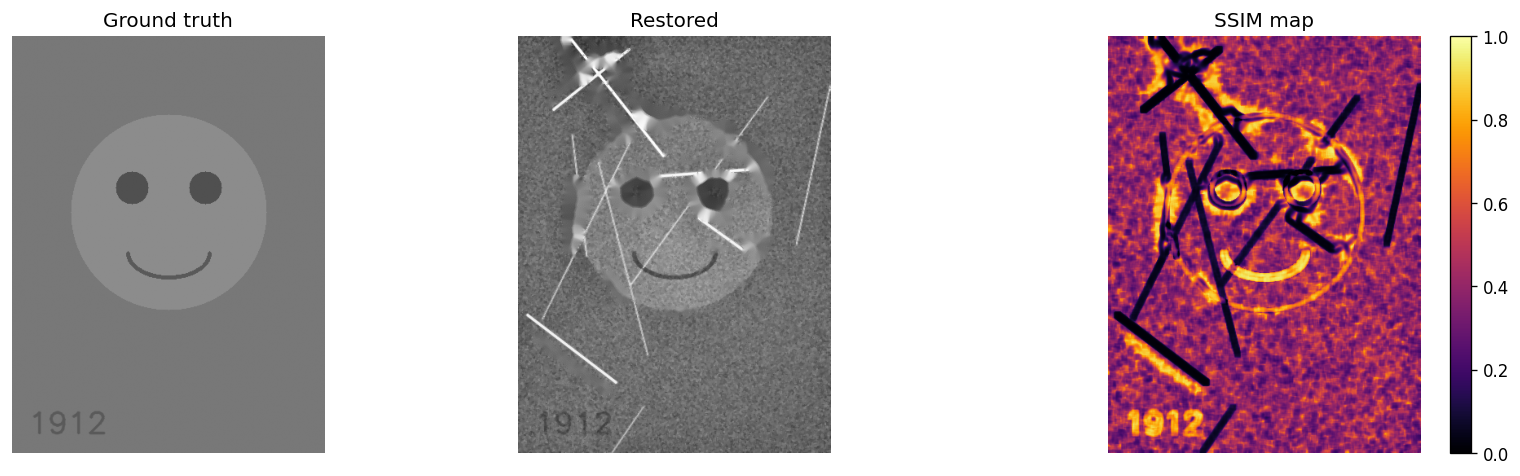

In [229]:
# SSIM (requires scikit-image)
try:
    from skimage.metrics import structural_similarity as ssim
except Exception:
    ssim = None

if gt is not None:
    if ssim is not None:
        print("SSIM:", float(ssim(gt, img_out, data_range=255)))
    else:
        print("SSIM not available (pip install scikit-image).")

score, ssim_map = ssim(gt, img_out, data_range=255, full=True)

plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
plt.imshow(gt, cmap="gray", vmin=0, vmax=255)
plt.title("Ground truth")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(img_out, cmap="gray", vmin=0, vmax=255)
plt.title("Restored")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(ssim_map, cmap="inferno", vmin=0, vmax=1)
plt.title("SSIM map")
plt.axis("off")
plt.colorbar(fraction=0.046)

plt.tight_layout()
plt.show()


# Build restoration pipeline

## Create synthetic degradation
1. fading
2. dust
3. scratches
4. grain noise


utitle fn
Logger setup specifically for Jupyter Notebook:



In [253]:
import logging
from pathlib import Path
from datetime import datetime

def create_dir(name):
    """Creates directory if it doesn't exist."""
    path = Path(name)
    path.mkdir(parents=True, exist_ok=True)
    logger.info(f"Directory created: {path}")
    return path

def setup_logger(log_dir="logs", log_file=None):
    """Setup logger for Jupyter Notebook."""

    # Convert log_dir to Path object and create it
    log_dir = Path(log_dir)
    log_dir.mkdir(parents=True, exist_ok=True)

    # Create log file name with timestamp if not provided
    if log_file is None:
        log_file = f"notebook_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"

    log_path = log_dir / log_file

    # Create logger
    logger = logging.getLogger("notebook_logger")
    logger.setLevel(logging.DEBUG)

    # Avoid duplicate handlers
    if not logger.handlers:
        # File handler
        file_handler = logging.FileHandler(log_path)
        file_handler.setLevel(logging.DEBUG)

        # Console handler
        console_handler = logging.StreamHandler()
        console_handler.setLevel(logging.INFO)

        # Format
        formatter = logging.Formatter(
            "%(asctime)s - %(levelname)s - %(message)s",
            datefmt="%Y-%m-%d %H:%M:%S"
        )
        file_handler.setFormatter(formatter)
        console_handler.setFormatter(formatter)

        # Add handlers
        logger.addHandler(file_handler)
        logger.addHandler(console_handler)

    logger.info(f"Logger initialized: {log_path}")
    return logger

# Initialize logger
logger = setup_logger()





2026-03-02 22:01:27 - INFO - Logger initialized: logs/notebook_20260302_220127.log


In [254]:
import os
import cv2 as cv
import numpy as np
from typing import Optional, Callable, Dict, Any
from matplotlib import pyplot as plt


class ImageData:
    """
    A container for images moving through a processing pipeline.

    Each instance represents one stage in the pipeline (e.g., original,
    white-balanced, gamma-corrected). Applying a processing function always
    returns a NEW ImageData object, so every stage is preserved independently.

    Typical usage:
        raw    = ImageData.from_path("photo.jpg")
        wb     = raw.apply(white_balance, "white_balance")
        gc     = wb.apply(gamma_correct,  "gamma", gamma=2.2)
        dn     = gc.apply(denoise,        "denoised")

        ImageData.compare_multiple(raw, wb, gc, dn)
        ImageData.save_all_stages([raw, wb, gc, dn], "./results")
    """

    def __init__(
        self,
        image: np.ndarray,
        name: str = "unnamed",
        process: str = "original",
        metadata: Optional[Dict[str, Any]] = None
    ):
        """
        Build an ImageData from a NumPy array.

        Prefer ImageData.from_path() when loading from disk.
        This constructor is intended for when you already have
        an array in memory (e.g., freshly decoded or synthesized).

        Args:
            image    : BGR image array (as returned by cv2.imread).
                       A copy is made so the caller's array is never modified.
            name     : Human-readable label used in plot titles and filenames.
            process  : Tag describing what was done to produce this image.
                       Defaults to "original" for the first stage.
            metadata : Arbitrary key-value pairs that travel with the image
                       (e.g., camera settings, previous process name).
        """
        # Keep an untouched copy of whatever was passed in.
        # self.original is never modified after this point.
        self.original = image.copy()

        # self.image is the array every method reads and writes.
        # It starts identical to original but can be replaced by apply().
        self.image = image.copy()

        self.name     = name
        self.process  = process
        self.path     = ""            # filled in by save() or from_path()
        self.metadata = metadata or {}

        # Derive shape/dtype/channel helpers from the current array.
        self._update_properties()

    # ------------------------------------------------------------------
    # Alternative constructors
    # ------------------------------------------------------------------

    @classmethod
    def from_path(cls, path: str, name: Optional[str] = None) -> "ImageData":
        """
        Load an image from disk and wrap it in ImageData.

        Separating file-loading into its own constructor keeps __init__
        simple (array-only) and makes the two code paths explicit.

        Args:
            path : Absolute or relative path to the image file.
            name : Label for the image. Defaults to the filename stem
                   (e.g., "photo" for "photo.jpg") if not provided.

        Returns:
            A new ImageData with process="original" and path set.

        Raises:
            FileNotFoundError: If the path does not exist or cv2 cannot
                               decode the file.
        """
        if not os.path.exists(path):
            raise FileNotFoundError(f"Image file not found: {path}")

        image = cv.imread(path, cv.IMREAD_COLOR)  # returns BGR array or None
        if image is None:
            raise FileNotFoundError(f"cv2 could not decode image: {path}")

        # Default name = filename without extension ("photo.jpg" → "photo")
        if name is None:
            name = os.path.splitext(os.path.basename(path))[0]

        instance = cls(image=image, name=name)
        instance.path = path   # record where this image came from
        return instance

    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------

    def _update_properties(self):
        """
        Sync convenience attributes with the current self.image array.

        Called once in __init__. If you ever replace self.image directly
        (rather than using apply()), call this afterwards so that height,
        width, channels, etc. stay accurate.
        """
        self.shape       = self.image.shape
        self.dtype       = self.image.dtype
        self.height      = self.shape[0]
        self.width       = self.shape[1]
        # Grayscale arrays are 2-D (H, W); colour arrays are 3-D (H, W, C).
        self.channels    = self.shape[2] if len(self.shape) > 2 else 1
        self.is_grayscale = self.channels == 1

    # ------------------------------------------------------------------
    # Properties
    # ------------------------------------------------------------------

    @property
    def rgb(self) -> np.ndarray:
        """
        Return the image in RGB channel order for matplotlib display.

        OpenCV stores colour images as BGR (Blue-Green-Red).
        matplotlib's imshow() expects RGB (Red-Green-Blue).
        Without this conversion every displayed image has its red
        and blue channels swapped, producing an unnatural colour cast.

        Grayscale images are returned as-is (no channel axis to swap).
        """
        if self.is_grayscale:
            return self.image
        return cv.cvtColor(self.image, cv.COLOR_BGR2RGB)

    # ------------------------------------------------------------------
    # Core pipeline method
    # ------------------------------------------------------------------

    def apply(
        self,
        process_fn: Callable,
        process_name: str,
        **kwargs
    ) -> "ImageData":
        """
        Apply a processing function and return the result as a new ImageData.

        This method is intentionally non-destructive: self is never changed.
        The caller receives a fresh object whose self.original holds the
        output of process_fn, making every pipeline stage independently
        inspectable or saveable.

        Args:
            process_fn   : Any callable with signature
                           process_fn(image: np.ndarray, **kwargs) -> np.ndarray.
                           It receives self.image (BGR array) as its first argument.
            process_name : Label for the new stage (e.g., "gamma", "denoised").
                           Used in plot titles, filenames, and subdirectory names.
            **kwargs     : Extra keyword arguments forwarded to process_fn
                           (e.g., gamma=2.2, sigma=1.5).

        Returns:
            A new ImageData containing the processed image.
            The new object's metadata records which process produced it.

        Example:
            denoised = raw.apply(cv.GaussianBlur, "gaussian_blur",
                                 ksize=(5, 5), sigmaX=0)
        """
        processed = process_fn(self.image, **kwargs)

        return ImageData(
            image    = processed,
            name     = self.name,
            process  = process_name,
            # Carry existing metadata forward and note the previous stage
            # so the full provenance chain can be reconstructed if needed.
            metadata = {**self.metadata, "previous_process": self.process}
        )

    # ------------------------------------------------------------------
    # Saving
    # ------------------------------------------------------------------

    def save(
        self,
        output_path: str,
        prefix: str = "",
        organize_by_process: bool = True
    ) -> str:
        """
        Write self.image to disk.

        When organize_by_process=True the file is placed in a subdirectory
        named after self.process, keeping each pipeline stage separate:

            output_path/
                original/
                    photo.jpg
                white_balance/
                    photo.jpg
                gamma/
                    photo.jpg

        Args:
            output_path         : Root directory for all saved files.
            prefix              : Optional string prepended to the filename
                                  (e.g., "exp01" → "exp01_photo.jpg").
            organize_by_process : Create a self.process subdirectory when True.
                                  Pass False to save directly into output_path.

        Returns:
            The absolute path of the file that was written.
        """
        if organize_by_process and self.process:
            # Sanitize the process tag so it is safe to use as a directory name.
            # Replace special characters that are invalid on most filesystems.
            process_dir = (
                self.process.lower()
                .replace(" ", "_")
                .replace("/", "_")
                .replace("γ", "gamma")   # Greek gamma (γ) → ascii "gamma"
                .replace("σ", "sigma")   # Greek sigma (σ) → ascii "sigma"
                .replace("=", "_")
                .replace(".", "_")
            )
            full_output_path = os.path.join(output_path, process_dir)
        else:
            full_output_path = output_path

        os.makedirs(full_output_path, exist_ok=True)

        # Sanitize the image name for the filename as well.
        safe_name = self.name.replace(" ", "_").replace("/", "_")
        filename  = f"{prefix}_{safe_name}.jpg" if prefix else f"{safe_name}.jpg"
        full_path = os.path.join(full_output_path, filename)

        cv.imwrite(full_path, self.image)
        self.path = full_path   # update so callers can find the file

        print(f"Saved: {full_path}")
        return full_path

    # ------------------------------------------------------------------
    # Display
    # ------------------------------------------------------------------

    def show(self, figsize: tuple = (8, 6)):
        """
        Display the image in a matplotlib window.

        Uses self.rgb (not self.image) so colours are rendered correctly
        regardless of whether the array is BGR or grayscale.

        Args:
            figsize : (width, height) in inches passed to plt.figure().
        """
        plt.figure(figsize=figsize)
        plt.imshow(self.rgb)
        plt.title(f"{self.name}  [{self.process}]")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

    # ------------------------------------------------------------------
    # Static / class-level utilities
    # ------------------------------------------------------------------

    @staticmethod
    def save_all_stages(
        images: list,
        output_path: str,
        prefix: str = ""
    ) -> Dict[str, str]:
        """
        Save every stage in a pipeline list with one call.

        Iterates over the list and calls img.save() on each non-None entry.
        Each image is placed in its own process subdirectory automatically
        (organize_by_process=True is always used here).

        Args:
            images      : List of ImageData objects (None entries are skipped).
            output_path : Root directory that will contain all stage folders.
            prefix      : Optional filename prefix applied to every file.

        Returns:
            A dict mapping each process name to the path where it was saved,
            e.g. {"original": ".../original/photo.jpg",
                  "gamma":    ".../gamma/photo.jpg"}.
        """
        saved_paths: Dict[str, str] = {}

        for img in images:
            if img is not None:
                path = img.save(output_path, prefix, organize_by_process=True)
                saved_paths[img.process] = path

        return saved_paths

    @staticmethod
    def compare_multiple(
        *images: "ImageData",
        figsize_per_img: tuple = (5, 4),
        save_path: Optional[str] = None,
        title: Optional[str] = None
    ):
        """
        Lay out any number of pipeline stages side by side in one figure.

        Each subplot shows one ImageData and is labelled with its process tag.
        Useful for quickly spotting the visual difference each step makes.

        Args:
            *images         : Any number of ImageData objects to display.
                              None values produce an empty "No Image" subplot.
            figsize_per_img : (width, height) in inches for a single subplot.
                              Total figure width = n * figsize_per_img[0].
            save_path       : If provided, the figure is saved to this path
                              before plt.show() is called.
            title           : Optional super-title shown above all subplots.

        Example:
            ImageData.compare_multiple(raw, wb, gc, dn,
                                       title="Full Pipeline",
                                       save_path="pipeline.png")
        """
        n = len(images)
        if n == 0:
            print("No images to compare.")
            return

        fig, axes = plt.subplots(
            1, n,
            figsize=(n * figsize_per_img[0], figsize_per_img[1])
        )

        # plt.subplots returns a single Axes (not a list) when n == 1.
        # Wrap it so the loop below can always index with axes[i].
        if n == 1:
            axes = [axes]

        for i, img in enumerate(images):
            if img is not None:
                axes[i].imshow(img.rgb)
                axes[i].set_title(f"[{img.process}]", fontsize=10)
            else:
                # Keep the grid consistent even if a stage is missing.
                axes[i].set_title("No Image", fontsize=10)
            axes[i].axis("off")

        if title:
            plt.suptitle(title, fontsize=14, fontweight="bold")

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="white")
            print(f"Saved comparison figure: {save_path}")

        plt.show()

    # ------------------------------------------------------------------
    # Dunder helpers
    # ------------------------------------------------------------------

    def __repr__(self) -> str:
        """
        Unambiguous string representation for debugging.

        Shows the three most useful facts at a glance:
        what the image is called, what stage produced it, and its dimensions.

        Example:
            ImageData(name='photo', process='gamma', shape=(1080, 1920, 3))
        """
        return (
            f"ImageData("
            f"name='{self.name}', "
            f"process='{self.process}', "
            f"shape={self.shape})"
        )

### Synthetic Image Degrader

In [255]:
import re
from pathlib import Path

import cv2 as cv
import numpy as np

class ImageDegrader:
    """Applies synthetic aging effects to grayscale images."""

    def __init__(self, img_path):
        self.img_path = img_path
        self.rng = np.random.default_rng()

    def add_fading(self, img, strength=0.35):
        """Reduces contrast and adds vignette effect."""
        imgf = img.astype(np.float32)
        imgf = imgf * (1.0 - strength) + 128 * strength
        h, w = img.shape
        yy, xx = np.mgrid[0:h, 0:w]
        cy, cx = h / 2, w / 2
        r = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2) / np.sqrt(cy ** 2 + cx ** 2)
        vign = 1.0 - 0.25 * r
        imgf = imgf * vign
        return np.clip(imgf, 0, 255).astype(np.uint8)

    def add_dust(self, img, p=0.006):
        """Adds random dust particles (black/white pixels)."""
        out = img.copy()
        mask = self.rng.random(img.shape) < p
        out[mask] = self.rng.choice([0, 255], size=mask.sum()).astype(np.uint8)
        return out

    def add_scratches(self, img, n_lines=16):
        """Adds random bright scratch lines."""
        out = img.copy()
        h, w = img.shape
        for _ in range(n_lines):
            x1 = int(self.rng.integers(0, w))
            y1 = int(self.rng.integers(0, h))
            x2 = int(np.clip(x1 + self.rng.integers(-w // 2, w // 2), 0, w - 1))
            y2 = int(np.clip(y1 + self.rng.integers(-h // 2, h // 2), 0, h - 1))
            thickness = int(self.rng.integers(1, 3))
            color = int(self.rng.integers(210, 255))
            cv.line(out, (x1, y1), (x2, y2), color, thickness, cv.LINE_AA)
        return out

    def add_grain(self, img, sigma=9.0):
        """Adds Gaussian noise to simulate film grain."""
        n = self.rng.normal(0, sigma, img.shape).astype(np.float32)
        out = np.clip(img.astype(np.float32) + n, 0, 255).astype(np.uint8)
        return out

    def degrade(self, img, fading_strength=0.35, grain_sigma=9.0,
                dust_p=0.006, n_scratches=11):
        """Applies all degradation effects in sequence."""
        out = img.copy()
        out = self.add_fading(out, strength=fading_strength)
        out = self.add_grain(out, sigma=grain_sigma)
        out = self.add_dust(out, p=dust_p)
        out = self.add_scratches(out, n_lines=n_scratches)
        return out

    def img_degradation(self, img, deg_effect_dict: dict):
        """Applies all degradation effects in sequence."""
        out = img.copy()
        if deg_effect_dict.get('fading'):
            out = self.add_fading(out, strength=deg_effect_dict.get('fading_strength', 0.35))
        if deg_effect_dict.get('grain'):
            out = self.add_grain(out, sigma=deg_effect_dict.get('grain_sigma', 9.0))
        if deg_effect_dict.get('dust'):
            out = self.add_dust(out, p=deg_effect_dict.get('dust_p', 0.006))
        if deg_effect_dict.get('scratches'):
            out = self.add_scratches(out, n_lines=deg_effect_dict.get('n_scratches', 11))
        # save out to old_Photos
        saved_path = self.save_incremented(out)
        return out, saved_path

    def save_incremented(self, img, directory="old_Photos", prefix="old_photo", ext=".jpg"):
        """Saves image with auto-incremented filename."""

        output_dir = Path(directory)
        output_dir.mkdir(exist_ok=True)

        # Get the next available number
        existing_files = output_dir.glob(f"{prefix}_*{ext}")
        numbers = [int(re.search(rf"{prefix}_(\d+)", f.stem).group(1)) for f in existing_files if re.search(rf"{prefix}_(\d+)", f.stem)]
        next_num = max(numbers, default=0) + 1

        # Save the image
        output_path = output_dir / f"{prefix}_{next_num}{ext}"
        cv.imwrite(str(output_path), img)
        logger.info(f"Saved: {output_path}")
        return output_path



In [233]:

# additional photos

from pathlib import Path
import cv2 as cv

def get_photos(directory):
    """Get all photos in the specified directory."""
    directory_path = Path(directory)  # Convert string to Path object
    logger.info(f"Looking in: {directory_path}")
    return [
        file for file in directory_path.glob("*.*")
        if (img := cv.imread(str(file), cv.IMREAD_UNCHANGED)) is not None
    ]



In [256]:
photos = sorted(get_photos("photos"))
logger.info(f"photos: {photos}")

2026-03-02 22:01:36 - INFO - Looking in: photos
2026-03-02 22:01:37 - INFO - photos: [PosixPath('photos/ground_truth.png'), PosixPath('photos/old_photo_31.jpg'), PosixPath('photos/old_photo_32.jpg'), PosixPath('photos/old_photo_33.jpg'), PosixPath('photos/old_photo_34.jpg'), PosixPath('photos/quantitative_evaluation_old_31.png')]


### Image Degrader widgets

In [235]:
%matplotlib inline

In [257]:
import ipywidgets as widgets
from ipywidgets import interact, interactive_output
from IPython.display import display, clear_output
import io

IMG_PATH = photos[0]

degrader = ImageDegrader(IMG_PATH if Path(IMG_PATH).exists() else "")

#______________________________________
# default values degradation_effect_dict
#______________________________________

degradation_effect_dict = {
        'fading': True,
        'fading_strength': 0.35,
        'grain': True,
        'grain_sigma': 9.0,
        'dust': True,
        'dust_p': 0.006,
        'scratches': True,
        'n_scratches': 11
    }

def render_pipeline(en_fading=True, fading=0.35,
                    en_grain=True, grain=9.0,
                    en_dust=True, dust=0.006,
                    en_scratches=True, scratches=11):
    """
    Renders the degradation pipeline with interactive parameters.
    """

    global degradation_effect_dict
    logger.info('--------------before degradation_effect_dict-------------------')
    logger.info(f'{degradation_effect_dict}')   # <-- f-string
    logger.info('--------------before degradation_effect_dict-------------------')

    # Build degradation dict from widget parameters
    degradation_effect_dict = {
        'fading': en_fading,
        'fading_strength': fading,
        'grain': en_grain,
        'grain_sigma': grain,
        'dust': en_dust,
        'dust_p': dust,
        'scratches': en_scratches,
        'n_scratches': scratches
    }

    logger.info('--------------after degradation_effect_dict-------------------')
    logger.info(f'{degradation_effect_dict}')   # <-- f-string
    logger.info('--------------after degradation_effect_dict-------------------')
    

interact(
    render_pipeline,
    en_fading=True,
    fading=widgets.FloatSlider(value=0.35, min=0.0, max=1.0, step=0.05, description='Fading Strength'),
    en_grain=True,
    grain=widgets.FloatSlider(value=9.0, min=0.0, max=30.0, step=0.5, description='Grain Sigma'),
    en_dust=True,
    dust=widgets.FloatSlider(value=0.006, min=0.0, max=0.05, step=0.001, description='Dust Prob', readout_format='.3f'),
    en_scratches=True,
    scratches=widgets.IntSlider(value=11, min=0, max=50, step=1, description='Scratches'),
);

interactive(children=(Checkbox(value=True, description='en_fading'), FloatSlider(value=0.35, description='Fadi…

In [237]:


# Get already degraded photo stems to avoid duplicates
old_photos_dir = create_dir("old_Photos")
already_degraded = sorted([f.stem for f in old_photos_dir.glob("*.*")])
logger.info(f"Already degraded photos: {already_degraded}")

for photo_path in photos:
    photo_stem = Path(photo_path).stem

    # Skip if already degraded
    if any(photo_stem in name for name in already_degraded):
        logger.info(f"Skipping {photo_stem} - already degraded")
        continue

    img = cv.imread(str(photo_path), cv.IMREAD_GRAYSCALE)
    degrader = ImageDegrader(photo_path)
    degraded_img, saved_path = degrader.img_degradation(img, degradation_effect_dict)
    logger.info(f"Degraded: {photo_path} -> {saved_path}")
    show(degraded_img, f"Degraded: {photo_stem}")

2026-03-02 20:40:29 - INFO - Directory created: old_Photos
2026-03-02 20:40:29 - INFO - Already degraded photos: ['old_photo_01', 'old_photo_02', 'old_photo_03', 'old_photo_04', 'old_photo_05', 'old_photo_06', 'old_photo_07', 'old_photo_08', 'old_photo_09', 'old_photo_10', 'old_photo_11', 'old_photo_12', 'old_photo_13', 'old_photo_14', 'old_photo_15', 'old_photo_16', 'old_photo_19', 'old_photo_20', 'old_photo_21', 'old_photo_22', 'old_photo_23', 'old_photo_24', 'old_photo_25', 'old_photo_26', 'old_photo_27', 'old_photo_28', 'old_photo_29', 'old_photo_30', 'old_photo_31', 'old_photo_32', 'old_photo_33', 'old_photo_34']
2026-03-02 20:40:29 - INFO - Skipping old_photo_31 - already degraded
2026-03-02 20:40:29 - INFO - Skipping old_photo_32 - already degraded
2026-03-02 20:40:29 - INFO - Skipping old_photo_33 - already degraded
2026-03-02 20:40:29 - INFO - Skipping old_photo_34 - already degraded


# LTI Filters
## Frequency Analysis with the DFT
---

##### Setup path to images = Old_Photos which contains the real old photos.  

In [258]:
photos = sorted(get_photos("Old_Photos"))
logger.info(f'{photos}')

2026-03-02 22:01:50 - INFO - Looking in: Old_Photos
2026-03-02 22:01:51 - INFO - [PosixPath('Old_Photos/old_photo_01.jpg'), PosixPath('Old_Photos/old_photo_02.jpg'), PosixPath('Old_Photos/old_photo_03.jpg'), PosixPath('Old_Photos/old_photo_04.jpg'), PosixPath('Old_Photos/old_photo_05.jpg'), PosixPath('Old_Photos/old_photo_06.jpg'), PosixPath('Old_Photos/old_photo_07.jpg'), PosixPath('Old_Photos/old_photo_08.jpeg'), PosixPath('Old_Photos/old_photo_09.jpeg'), PosixPath('Old_Photos/old_photo_10.jpg'), PosixPath('Old_Photos/old_photo_11.jpg'), PosixPath('Old_Photos/old_photo_12.jpg'), PosixPath('Old_Photos/old_photo_13.jpg'), PosixPath('Old_Photos/old_photo_14.jpg'), PosixPath('Old_Photos/old_photo_15.jpg'), PosixPath('Old_Photos/old_photo_16.jpg'), PosixPath('Old_Photos/old_photo_19.jpg'), PosixPath('Old_Photos/old_photo_20.jpg'), PosixPath('Old_Photos/old_photo_21.jpg'), PosixPath('Old_Photos/old_photo_22.jpg'), PosixPath('Old_Photos/old_photo_23.jpg'), PosixPath('Old_Photos/old_photo_24

* Create drop down for photos
* Compute DFT magnitude for each photo and display

In [259]:
def compute_power_spectrum_stats(Fshift, img_shape, low_freq_radius=10):
    """
    Computes power spectrum energy statistics from a shifted DFT.

    Parameters:
        Fshift           : shifted complex FFT output (from np.fft.fftshift)
        img_shape        : tuple (H, W) of the source image
        low_freq_radius  : half-size of the low-frequency window around DC (default: 10)

    Returns:
        stats : dict with keys:
                  'power'           : 2D power spectrum array
                  'low_freq_energy' : total energy in the low-freq region
                  'total_energy'    : total energy across all frequencies
                  'low_freq_ratio'  : low_freq_energy / total_energy (0–1)
                  'cy', 'cx'        : DC component center coordinates
    """
    h, w = img_shape
    cy, cx = h // 2, w // 2

    power           = np.abs(Fshift) ** 2
    low_freq_energy = float(power[
        cy - low_freq_radius : cy + low_freq_radius,
        cx - low_freq_radius : cx + low_freq_radius
    ].sum())
    total_energy    = float(power.sum()) + 1e-12
    low_freq_ratio  = low_freq_energy / total_energy

    return {
        'power'           : power,
        'low_freq_energy' : low_freq_energy,
        'total_energy'    : total_energy,
        'low_freq_ratio'  : low_freq_ratio,
        'cy'              : cy,
        'cx'              : cx,
    }


def compute_dft_magnitude(img_deg, save_path="figs/dft_magnitude.png", title="DFT magnitude (log)"):
    """
    Computes and visualizes the 2D DFT magnitude spectrum of a grayscale image.

    Parameters:
        img_deg     : 2D numpy array (grayscale image)
        save_path   : path to save the output image (default: "figs/dft_magnitude.png")
        title       : title for the display window (default: "DFT magnitude (log)")

    Returns:
        mag_u8      : normalized 8-bit log-magnitude spectrum
        Fshift      : shifted complex FFT output
    """
    F      = np.fft.fft2(img_deg)
    Fshift = np.fft.fftshift(F)
    mag    = np.log(np.abs(Fshift) + 1.0)
    mag_u8 = (255 * (mag - mag.min()) / (mag.max() - mag.min() + 1e-12)).astype(np.uint8)

    return mag_u8, Fshift


# ------------------------------------------------------------------
# Interactive widget for DFT magnitude
# ------------------------------------------------------------------

photo_options = [(Path(p).name, str(p)) for p in photos]

photo_dropdown = widgets.Dropdown(
    options=photo_options,
    description='Photo:',
    layout=widgets.Layout(width='400px')
)

out = widgets.Output()


def on_photo_selected(change):
    """Load selected photo, compute and display DFT magnitude."""
    with out:
        clear_output(wait=True)
        selected_path = photo_dropdown.value

        # Load as grayscale
        img = cv.imread(selected_path, cv.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Could not load: {selected_path}")
            return

        # Compute DFT magnitude
        mag_u8, Fshift = compute_dft_magnitude(img)

        # Compute power spectrum stats
        ps             = compute_power_spectrum_stats(Fshift, img.shape)
        low_freq_ratio = ps['low_freq_ratio']
        cy, cx         = ps['cy'], ps['cx']

        # Radial frequency profile
        mag_float = np.log(np.abs(Fshift) + 1.0)
        yy, xx    = np.mgrid[0:img.shape[0], 0:img.shape[1]]
        rr        = np.sqrt((yy - cy)**2 + (xx - cx)**2).astype(int)
        max_r     = min(cy, cx)
        radial    = np.array([
            mag_float[rr == r].mean() if (rr == r).any() else 0
            for r in range(max_r)
        ])

        fig, axes = plt.subplots(1, 3, figsize=(16, 5))

        # ── Col 0 : Original image ────────────────────────────────────
        axes[0].imshow(img, cmap="gray")
        axes[0].set_title(f"Original\n{img.shape[1]}×{img.shape[0]} px", fontsize=10)
        axes[0].axis("off")

        # ── Col 1 : DFT magnitude spectrum ────────────────────────────
        axes[1].imshow(mag_u8, cmap="gray")
        axes[1].set_title(
            f"DFT Magnitude (log scale)\n"
            f"Low-freq energy: {low_freq_ratio*100:.1f}%",
            fontsize=10
        )
        axes[1].axis("off")

        # ── Col 2 : Radial frequency profile ──────────────────────────
        axes[2].plot(radial, color="steelblue", linewidth=1.5)
        axes[2].set_title("Radial Frequency Profile", fontsize=10)
        axes[2].set_xlabel("Radial distance from DC (pixels)")
        axes[2].set_ylabel("Mean log-magnitude (log|F|)")
        axes[2].grid(True, alpha=0.3)

        plt.suptitle(
            f"DFT Analysis — {Path(selected_path).name}",
            fontsize=12, fontweight="bold"
        )
        plt.tight_layout()

        save_path = f"figs/dft_{Path(selected_path).stem}.png"
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
        logger.info(f"DFT magnitude saved: {save_path}")
        plt.show()


photo_dropdown.observe(on_photo_selected, names='value')

display(photo_dropdown, out)

on_photo_selected({'new': photo_options[0][1]})

Dropdown(description='Photo:', layout=Layout(width='400px'), options=(('old_photo_01.jpg', 'Old_Photos/old_pho…

Output()

## Derivatives and Gradients
---

In [260]:
import ipywidgets as widgets
from IPython.display import display, clear_output


def compute_gaussian_smoothing(img, sigmas=[1, 2, 5, 10, 15, 20],
                                save_path="figs/gaussian_smoothing.png",
                                title="Gaussian Smoothing"):
    """
    Applies Gaussian smoothing at multiple sigma values.

    Parameters:
        img         : 2D numpy array (grayscale image)
        sigmas      : list of sigma values to apply
        save_path   : path to save the output figure (default: "figs/gaussian_smoothing.png")
        title       : title for the display window

    Returns:
        blurred     : dict mapping sigma -> blurred uint8 image
    """
    blurred = {}

    for s in sigmas:
        blurred[s] = cv.GaussianBlur(img, (0, 0), sigmaX=s, sigmaY=s)

    return blurred


# ------------------------------------------------------------------
# Interactive widget for Gaussian smoothing
# ------------------------------------------------------------------

photo_options = [(Path(p).name, str(p)) for p in photos]

photo_dropdown_gauss = widgets.Dropdown(
    options=photo_options,
    description='Photo:',
    layout=widgets.Layout(width='400px')
)

sigma_slider = widgets.IntSlider(
    value=5,
    min=1,
    max=100,
    step=1,
    description='σ value:',
    layout=widgets.Layout(width='400px')
)

out_gauss = widgets.Output()


def on_gaussian_selected(change):
    """Load selected photo, apply Gaussian smoothing and display."""
    with out_gauss:
        clear_output(wait=True)
        selected_path = photo_dropdown_gauss.value
        sigma         = sigma_slider.value

        img = cv.imread(selected_path, cv.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Could not load: {selected_path}")
            return

        # Only compute for the selected sigma
        blurred = compute_gaussian_smoothing(img, sigmas=[sigma])

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        axes[0].imshow(img, cmap="gray")
        axes[0].set_title("Original")
        axes[0].axis("off")

        axes[1].imshow(blurred[sigma], cmap="gray")
        axes[1].set_title(f"σ={sigma}")
        axes[1].axis("off")

        plt.suptitle(f"Gaussian Smoothing — {Path(selected_path).name}", fontsize=12)
        plt.tight_layout()

        save_path = f"figs/gaussian_{Path(selected_path).stem}_sigma{sigma}.png"
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
        logger.info(f"Gaussian smoothing saved: {save_path}")
        plt.show()


photo_dropdown_gauss.observe(on_gaussian_selected, names='value')
sigma_slider.observe(on_gaussian_selected, names='value')

display(photo_dropdown_gauss, sigma_slider, out_gauss)
on_gaussian_selected({'new': photo_options[0][1]})

Dropdown(description='Photo:', layout=Layout(width='400px'), options=(('old_photo_01.jpg', 'Old_Photos/old_pho…

IntSlider(value=5, description='σ value:', layout=Layout(width='400px'), min=1)

Output()

In [261]:
def compute_gradients(img, ksizes=[1, 3, 5, 7],
                      save_path="figs/gradient_magnitude.png",
                      title="Gradient Magnitude (Sobel)"):
    """
    Computes Sobel gradients and gradient magnitude at multiple kernel sizes.

    Parameters:
        img         : 2D numpy array (grayscale image)
        ksizes      : list of kernel sizes to apply (odd integers; use -1 for Scharr)
                      common values: 1, 3, 5, 7; -1 = Scharr filter
        save_path   : path to save the output figure (default: "figs/gradient_magnitude.png")
        title       : title for the display window

    Returns:
        gradients   : dict mapping ksize -> dict with keys:
                        'gx'   : x-derivative (float64)
                        'gy'   : y-derivative (float64)
                        'gmag' : gradient magnitude (uint8, normalized)
    """
    gradients = {}

    for k in ksizes:
        gx      = cv.Sobel(img, cv.CV_64F, 1, 0, ksize=k)
        gy      = cv.Sobel(img, cv.CV_64F, 0, 1, ksize=k)
        gmag    = np.sqrt(gx**2 + gy**2)
        gmag_u8 = cv.normalize(gmag, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

        gradients[k] = {
            'gx'   : gx,
            'gy'   : gy,
            'gmag' : gmag_u8
        }

    return gradients


# ------------------------------------------------------------------
# Interactive widget for gradient visualization
# ------------------------------------------------------------------

photo_dropdown_grad = widgets.Dropdown(
    options=photo_options,
    description='Photo:',
    layout=widgets.Layout(width='400px')
)

ksize_slider = widgets.IntSlider(
    value=3,
    min=1,
    max=7,
    step=2,
    description='k size:',
    layout=widgets.Layout(width='400px')
)

sigma_grad_slider = widgets.IntSlider(
    value=3,
    min=0,
    max=20,
    step=1,
    description='σ (pre-blur):',
    layout=widgets.Layout(width='400px')
)

out_grad = widgets.Output()


def on_gradient_selected(change):
    """Load selected photo, compute gradients and display."""
    with out_grad:
        clear_output(wait=True)
        selected_path = photo_dropdown_grad.value
        ksize         = ksize_slider.value
        sigma         = sigma_grad_slider.value

        img = cv.imread(selected_path, cv.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Could not load: {selected_path}")
            return

        # Optional pre-smoothing
        img_smooth = cv.GaussianBlur(img, (0, 0), sigma, sigma) if sigma > 0 else img

        # Compute gradients for selected ksize only
        grad_smooth = compute_gradients(img_smooth, ksizes=[ksize])

        fig, axes = plt.subplots(1, 3, figsize=(14, 4))

        # ── Col 0 : Original / smoothed image ────────────────────────
        axes[0].imshow(img_smooth, cmap="gray")
        axes[0].set_title(f"Smoothed σ={sigma}" if sigma > 0 else "Original")
        axes[0].axis("off")

        # ── Col 1 : x-derivative ─────────────────────────────────────
        axes[1].imshow(grad_smooth[ksize]['gx'], cmap="gray")
        axes[1].set_title(f"Iₓ  (k={ksize})")
        axes[1].axis("off")

        # ── Col 2 : Gradient magnitude ───────────────────────────────
        axes[2].imshow(grad_smooth[ksize]['gmag'], cmap="gray")
        axes[2].set_title(f"|∇I|  (k={ksize})")
        axes[2].axis("off")

        plt.suptitle(f"Derivatives & Gradients — {Path(selected_path).name}", fontsize=12)
        plt.tight_layout()

        save_path = f"figs/gradient_{Path(selected_path).stem}_k{ksize}_s{sigma}.png"
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
        logger.info(f"Gradient magnitude saved: {save_path}")
        plt.show()


photo_dropdown_grad.observe(on_gradient_selected, names='value')
ksize_slider.observe(on_gradient_selected, names='value')
sigma_grad_slider.observe(on_gradient_selected, names='value')

display(photo_dropdown_grad, ksize_slider, sigma_grad_slider, out_grad)
on_gradient_selected({'new': photo_options[0][1]})

Dropdown(description='Photo:', layout=Layout(width='400px'), options=(('old_photo_01.jpg', 'Old_Photos/old_pho…

IntSlider(value=3, description='k size:', layout=Layout(width='400px'), max=7, min=1, step=2)

IntSlider(value=3, description='σ (pre-blur):', layout=Layout(width='400px'), max=20)

Output()


## Median Filtering for Dust/Speckles
---

In [263]:
def compute_median_filter(img, ksizes=[3, 5, 7],
                          save_path="figs/median_filtering.png",
                          title="Median Filtering"):
    """
    Applies median filtering at multiple kernel sizes.

    Parameters:
        img         : 2D numpy array (grayscale image)
        ksizes      : list of odd kernel sizes >= 3 (default: [3, 5, 7])
                      common values: 3, 5, 7
        save_path   : path to save the output figure (default: "figs/median_filtering.png")
        title       : title for the display window

    Returns:
        filtered    : dict mapping ksize -> filtered uint8 image
    """
    filtered = {}

    for k in ksizes:
        if k < 3 or k % 2 == 0:
            logger.warning(f"Skipping ksize={k}: must be odd and >= 3")
            continue
        filtered[k] = cv.medianBlur(img, ksize=k)

    return filtered

# ------------------------------------------------------------------
# Interactive widget for median filtering
# ------------------------------------------------------------------

photo_dropdown_med = widgets.Dropdown(
    options=photo_options,
    description='Photo:',
    layout=widgets.Layout(width='400px')
)

ksize_med_slider = widgets.SelectionSlider(
    options=[3, 5, 7, 9, 11, 13, 15, 17, 19, 21],
    value=3,
    description='k size:',
    layout=widgets.Layout(width='400px')
)

out_med = widgets.Output()

def on_median_selected(change):
    """Load selected photo, apply median filter and display."""
    with out_med:
        clear_output(wait=True)
        selected_path = photo_dropdown_med.value
        ksize         = ksize_med_slider.value

        img = cv.imread(selected_path, cv.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Could not load: {selected_path}")
            return

        # Only compute for the selected ksize
        filtered = compute_median_filter(img, ksizes=[ksize])

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        axes[0].imshow(img, cmap="gray")
        axes[0].set_title("Original")
        axes[0].axis("off")

        axes[1].imshow(filtered[ksize], cmap="gray")
        axes[1].set_title(f"Median k={ksize}")
        axes[1].axis("off")

        plt.suptitle(f"Median Filtering — {Path(selected_path).name}", fontsize=12)
        plt.tight_layout()

        save_path = f"figs/median_{Path(selected_path).stem}_k{ksize}.png"
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
        logger.info(f"Median filtering saved: {save_path}")
        plt.show()

photo_dropdown_med.observe(on_median_selected, names='value')
ksize_med_slider.observe(on_median_selected, names='value')

display(photo_dropdown_med, ksize_med_slider, out_med)
on_median_selected({'new': photo_options[0][1]})

Dropdown(description='Photo:', layout=Layout(width='400px'), options=(('old_photo_01.jpg', 'Old_Photos/old_pho…

SelectionSlider(description='k size:', layout=Layout(width='400px'), options=(3, 5, 7, 9, 11, 13, 15, 17, 19, …

Output()

# Morphological filtering for scratches/cracks
--- 

In [252]:
def compute_morphology(img, gmag_u8, thr_ratio=0.35,
                       morph_shape=cv.MORPH_ELLIPSE, kernel_size=5,
                       open_iter=1, close_iter=2,
                       save_path="figs/morphology.png",
                       title="Morphological Filtering"):
    """
    Computes morphological mask refinement and morphological gradient.

    Parameters:
        img          : 2D numpy array (grayscale image, e.g. median-filtered)
        gmag_u8      : 2D numpy array (uint8 gradient magnitude image)
        thr_ratio    : threshold as fraction of max gradient (default: 0.35)
        morph_shape  : structuring element shape (default: cv.MORPH_ELLIPSE)
        kernel_size  : size of the structuring element (default: 5)
        open_iter    : number of opening iterations (default: 1)
        close_iter   : number of closing iterations (default: 2)
        save_path    : path to save the output figure
        title        : title for the display window

    Returns:
        result : dict with keys:
                   mask, mask_open, mask_close,
                   mgrad, mgrad_u8, sobel_u8, diff_map,
                   kernel, thr
    """
    logger.info(
        f"compute_morphology called — "
        f"thr_ratio={thr_ratio}  morph_shape={morph_shape}  "
        f"kernel_size={kernel_size}  open_iter={open_iter}  close_iter={close_iter}"
    )

    thr     = int(thr_ratio * gmag_u8.max())
    _, mask = cv.threshold(gmag_u8, thr, 255, cv.THRESH_BINARY)
    logger.info(f"Threshold applied: thr={thr}  mask nonzero={np.count_nonzero(mask)} px")

    kernel     = cv.getStructuringElement(morph_shape, (kernel_size, kernel_size))
    mask_open  = cv.morphologyEx(mask,      cv.MORPH_OPEN,  kernel, iterations=open_iter)
    mask_close = cv.morphologyEx(mask_open, cv.MORPH_CLOSE, kernel, iterations=close_iter)
    logger.info(
        f"Morphology — after open: {np.count_nonzero(mask_open)} px  "
        f"after close: {np.count_nonzero(mask_close)} px"
    )

    # ── Morphological gradient: dilation − erosion ────────────────
    dil      = cv.dilate(img, kernel, iterations=1)
    ero      = cv.erode(img,  kernel, iterations=1)
    mgrad    = cv.subtract(dil, ero)
    mgrad_u8 = cv.normalize(mgrad, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
    logger.info(
        f"Morph gradient — mean={mgrad_u8.mean():.2f}  std={mgrad_u8.std():.2f}  "
        f"max={mgrad_u8.max()}"
    )

    # ── Sobel gradient magnitude on the same input ────────────────
    gx       = cv.Sobel(img, cv.CV_64F, 1, 0, ksize=3)
    gy       = cv.Sobel(img, cv.CV_64F, 0, 1, ksize=3)
    sobel    = np.sqrt(gx**2 + gy**2)
    sobel_u8 = cv.normalize(sobel, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
    logger.info(
        f"Sobel gradient — mean={sobel_u8.mean():.2f}  std={sobel_u8.std():.2f}  "
        f"max={sobel_u8.max()}"
    )

    # ── Absolute difference map ───────────────────────────────────
    diff_map = cv.absdiff(mgrad_u8, sobel_u8)
    logger.info(f"Abs diff map — mean={diff_map.mean():.2f}  max={diff_map.max()}")

    return {
        'mask'       : mask,
        'mask_open'  : mask_open,
        'mask_close' : mask_close,
        'mgrad'      : mgrad,
        'mgrad_u8'   : mgrad_u8,
        'sobel_u8'   : sobel_u8,
        'diff_map'   : diff_map,
        'kernel'     : kernel,
        'thr'        : thr,
    }


# ------------------------------------------------------------------
# Interactive widget for morphological filtering
# ------------------------------------------------------------------

photo_dropdown_morph = widgets.Dropdown(
    options=photo_options,
    description='Photo:',
    layout=widgets.Layout(width='400px')
)

thr_ratio_slider = widgets.FloatSlider(
    value=0.35, min=0.25, max=0.75, step=0.05,
    description='Thr ratio:', readout_format='.2f',
    layout=widgets.Layout(width='400px')
)

kernel_size_morph_slider = widgets.SelectionSlider(
    options=[3, 5, 7, 9, 11], value=5,
    description='Kernel size:',
    layout=widgets.Layout(width='400px')
)

morph_shape_dropdown = widgets.Dropdown(
    options=[
        ('Ellipse',   cv.MORPH_ELLIPSE),
        ('Rectangle', cv.MORPH_RECT),
        ('Cross',     cv.MORPH_CROSS),
    ],
    value=cv.MORPH_ELLIPSE,
    description='SE shape:',
    layout=widgets.Layout(width='400px')
)

out_morph = widgets.Output()


def on_morph_selected(change):
    """Load selected photo, apply morphological filtering and display."""
    with out_morph:
        clear_output(wait=True)
        selected_path = photo_dropdown_morph.value
        thr_ratio     = thr_ratio_slider.value
        kernel_size   = kernel_size_morph_slider.value
        morph_shape   = morph_shape_dropdown.value

        logger.info(
            f"on_morph_selected — photo={Path(selected_path).name}  "
            f"thr_ratio={thr_ratio}  kernel_size={kernel_size}  morph_shape={morph_shape}"
        )

        img = cv.imread(selected_path, cv.IMREAD_GRAYSCALE)
        if img is None:
            logger.error(f"Could not load image: {selected_path}")
            print(f"Could not load: {selected_path}")
            return

        logger.info(f"Image loaded — shape={img.shape}  dtype={img.dtype}")

        shape_name = {
            cv.MORPH_ELLIPSE : "ellipse",
            cv.MORPH_RECT    : "rect",
            cv.MORPH_CROSS   : "cross",
        }.get(morph_shape, "unknown")

        # ── Pre-processing ────────────────────────────────────────
        med     = cv.medianBlur(img, ksize=3)
        logger.info("Median blur (ksize=3) applied")

        gx      = cv.Sobel(med, cv.CV_64F, 1, 0, ksize=3)
        gy      = cv.Sobel(med, cv.CV_64F, 0, 1, ksize=3)
        gmag    = np.sqrt(gx**2 + gy**2)
        gmag_u8 = cv.normalize(gmag, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
        logger.info(
            f"Pre-Sobel on median image — "
            f"gmag max={gmag_u8.max()}  mean={gmag_u8.mean():.2f}"
        )

        result = compute_morphology(
            img         = med,
            gmag_u8     = gmag_u8,
            thr_ratio   = thr_ratio,
            morph_shape = morph_shape,
            kernel_size = kernel_size,
        )

        save_path = (
            f"figs/morph_{Path(selected_path).stem}"
            f"_k{kernel_size}"
            f"_t{int(thr_ratio*100)}"
            f"_{shape_name}.png"
        )

        # ── Figure 1: Mask pipeline ───────────────────────────────
        logger.info("Rendering Figure 1 — mask pipeline")
        fig, axes = plt.subplots(1, 4, figsize=(18, 4))

        axes[0].imshow(result['mask'],       cmap="gray")
        axes[0].set_title(f"Edge Mask\n(thr={result['thr']})", fontsize=10)
        axes[0].axis("off")

        axes[1].imshow(result['mask_open'],  cmap="gray")
        axes[1].set_title("After Opening\n(noise removed)", fontsize=10)
        axes[1].axis("off")

        axes[2].imshow(result['mask_close'], cmap="gray")
        axes[2].set_title("After Closing\n(gaps filled)", fontsize=10)
        axes[2].axis("off")

        axes[3].imshow(result['mgrad'],      cmap="gray")
        axes[3].set_title("Morph Gradient\n(edge detector)", fontsize=10)
        axes[3].axis("off")

        plt.suptitle(
            f"Morphology — {Path(selected_path).name}  "
            f"| SE: {shape_name}  kernel={kernel_size}×{kernel_size}  thr={thr_ratio:.2f}\n"
            f"saved: {Path(save_path).name}",
            fontsize=11, fontweight="bold"
        )
        plt.tight_layout()
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
        logger.info(f"Figure 1 saved: {save_path}")
        plt.show()

        # ── Figure 2: Morphological Gradient vs Sobel ────────────
        mgrad_u8 = result['mgrad_u8']
        sobel_u8 = result['sobel_u8']
        diff_map = result['diff_map']

        # binary edge maps at threshold=30
        _, morph_bin = cv.threshold(mgrad_u8, 30, 255, cv.THRESH_BINARY)
        _, sobel_bin = cv.threshold(sobel_u8, 30, 255, cv.THRESH_BINARY)

        morph_edge_density = float((morph_bin > 0).mean())
        sobel_edge_density = float((sobel_bin > 0).mean())

        logger.info(
            f"Edge density — morph={morph_edge_density:.4f}  "
            f"sobel={sobel_edge_density:.4f}"
        )

        logger.info("Rendering Figure 2 — MorphGrad vs Sobel")
        fig2, axes2 = plt.subplots(2, 3, figsize=(18, 9))

        # ── Row 0: continuous response maps ──────────────────────
        axes2[0, 0].imshow(med,      cmap="gray")
        axes2[0, 0].set_title("Input\n(median-filtered)", fontsize=10)
        axes2[0, 0].axis("off")

        axes2[0, 1].imshow(mgrad_u8, cmap="hot")
        axes2[0, 1].set_title(
            f"Morphological Gradient\n"
            f"(dilation − erosion, {shape_name} {kernel_size}×{kernel_size})",
            fontsize=10
        )
        axes2[0, 1].axis("off")

        axes2[0, 2].imshow(sobel_u8, cmap="hot")
        axes2[0, 2].set_title("Sobel Gradient Magnitude\n(ksize=3)", fontsize=10)
        axes2[0, 2].axis("off")

        # ── Row 1: binary + difference map ───────────────────────
        axes2[1, 0].imshow(diff_map,  cmap="hot")
        axes2[1, 0].set_title("Absolute Difference\n(|MorphGrad − Sobel|)", fontsize=10)
        axes2[1, 0].axis("off")

        axes2[1, 1].imshow(morph_bin, cmap="gray")
        axes2[1, 1].set_title(
            f"Morph Binary (thr=30)\nedge density = {morph_edge_density:.4f}",
            fontsize=10
        )
        axes2[1, 1].axis("off")

        axes2[1, 2].imshow(sobel_bin, cmap="gray")
        axes2[1, 2].set_title(
            f"Sobel Binary (thr=30)\nedge density = {sobel_edge_density:.4f}",
            fontsize=10
        )
        axes2[1, 2].axis("off")

        fig2.suptitle(
            f"Morphological Gradient vs Sobel — {Path(selected_path).name}\n"
            f"Morph: thicker edges, noise-sensitive  |  "
            f"Sobel: thinner edges, orientation-aware",
            fontsize=11, fontweight="bold"
        )
        plt.tight_layout()

        save_path_vs = (
            f"figs/morph_grad_vs_sobel_{Path(selected_path).stem}"
            f"_k{kernel_size}_{shape_name}.png"
        )
        plt.savefig(save_path_vs, dpi=120, bbox_inches="tight")
        logger.info(f"Figure 2 saved: {save_path_vs}")
        plt.show()

        # ── summary table via logger ──────────────────────────────
        logger.info(f"{'─'*65}")
        logger.info(f"{'Metric':<35} {'Morph Gradient':>18} {'Sobel':>10}")
        logger.info(f"{'─'*65}")
        logger.info(f"{'Mean response':<35} {mgrad_u8.mean():>18.2f} {sobel_u8.mean():>10.2f}")
        logger.info(f"{'Std response':<35} {mgrad_u8.std():>18.2f}  {sobel_u8.std():>10.2f}")
        logger.info(f"{'Edge density (thr=30)':<35} {morph_edge_density:>18.4f} {sobel_edge_density:>10.4f}")
        logger.info(f"{'Abs diff mean':<35} {diff_map.mean():>18.2f}")
        logger.info(f"{'─'*65}")
        logger.info(
            f"on_morph_selected complete — "
            f"photo={Path(selected_path).name}  "
            f"SE={shape_name}  k={kernel_size}  thr={thr_ratio:.2f}"
        )


photo_dropdown_morph.observe(on_morph_selected,     names='value')
thr_ratio_slider.observe(on_morph_selected,         names='value')
kernel_size_morph_slider.observe(on_morph_selected, names='value')
morph_shape_dropdown.observe(on_morph_selected,     names='value')

display(photo_dropdown_morph, thr_ratio_slider,
        kernel_size_morph_slider, morph_shape_dropdown, out_morph)
on_morph_selected({'new': photo_options[0][1]})

Dropdown(description='Photo:', layout=Layout(width='400px'), options=(('old_photo_01.jpg', 'Old_Photos/old_pho…

FloatSlider(value=0.35, description='Thr ratio:', layout=Layout(width='400px'), max=0.75, min=0.25, step=0.05)

SelectionSlider(description='Kernel size:', index=1, layout=Layout(width='400px'), options=(3, 5, 7, 9, 11), v…

Dropdown(description='SE shape:', layout=Layout(width='400px'), options=(('Ellipse', 2), ('Rectangle', 0), ('C…

Output()

------------------------------------------------------------------
# End-to-End Restoration Pipeline
----------------------------------------------------------------

In [249]:
def run_restoration_pipeline(
    img,
    do_norm        = True,
    do_gaussian    = True,  gauss_sigma    = 1.5,
    do_median      = True,  median_ksize   = 5,
    do_morph       = True,  thr_ratio      = 0.35,
    morph_shape    = cv.MORPH_ELLIPSE,
    morph_ksize    = 5,     open_iter      = 1,    close_iter     = 2,
    do_inpaint     = True,  inpaint_radius = 3,
    inpaint_method = cv.INPAINT_TELEA,
    do_clahe       = True,  clip_limit     = 2.0,  tile_grid      = (8, 8),
):
    from collections import OrderedDict
    stages  = OrderedDict()
    stages['0_input'] = img.copy()
    current = img.copy()

    # ── Step 1 : Contrast normalisation ──────────────────────────────
    if do_norm:
        current = cv.normalize(current, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
        stages['1_norm'] = current.copy()
        logger.info(
            f"Step 1 — contrast normalisation: stretched faded pixel intensities "
            f"to full range [0, 255] — image histogram now spans full dynamic range"
        )

    # ── Step 2 : Gaussian smoothing ───────────────────────────────────
    if do_gaussian:
        current = cv.GaussianBlur(current, (0, 0), gauss_sigma, gauss_sigma)
        stages['2_gaussian'] = current.copy()
        logger.info(
            f"Step 2 — Gaussian smoothing (sigma={gauss_sigma}): suppressed high-frequency "
            f"film grain and texture noise — edges preserved for scratch detection in step 4"
        )

    # ── Step 3 : Median filter ────────────────────────────────────────
    if do_median:
        current = cv.medianBlur(current, ksize=median_ksize)
        stages['3_median'] = current.copy()
        logger.info(
            f"Step 3 — median filter (k={median_ksize}x{median_ksize}): removed impulsive "
            f"dust and salt-pepper noise — edges intact because median ignores outlier pixels"
        )

    # ── Step 4 : Scratch mask ─────────────────────────────────────────
    mask_close = None
    if do_morph:

        cf = current.astype(np.float32)

        # ── 4a : Multi-scale bright-deviation ────────────────────────
        # Subtracts local background at 3 scales so thin AND wide
        # scratches both produce a strong positive response.
        bright_masks = []
        for sigma_bg in [3, 7, 15]:
            bg      = cv.GaussianBlur(cf, (0, 0), sigma_bg)
            dev     = np.clip(cf - bg, 0, None)
            dev_u8  = cv.normalize(dev, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
            thr_val = max(1, int(thr_ratio * dev_u8.max()))
            _, bm   = cv.threshold(dev_u8, thr_val, 255, cv.THRESH_BINARY)
            bright_masks.append(bm)

        scratch_bright = cv.bitwise_or(bright_masks[0],
                         cv.bitwise_or(bright_masks[1], bright_masks[2]))

        logger.info(
            f"Step 4a — multi-scale brightness (sigma=3,7,15) — "
            f"union pixels={np.count_nonzero(scratch_bright)}"
        )

        # ── 4b : Hessian ridge detector ──────────────────────────────
        # The Hessian matrix H = [[Ixx, Ixy],[Ixy, Iyy]] describes
        # local curvature. At a bright ridge (scratch):
        #   λ_min ≈ 0   (no curvature along the line)
        #   λ_max >> 0  (strong curvature across the line)
        # Ridge score R = |λ_max| with λ_max < 0 filtered out keeps
        # only BRIGHT ridges (not dark valleys).
        hessian_maps = []
        for sigma_h in [0.75, 1.5, 3.0]:
            # Second-order Gaussian derivatives (scale-normalised)
            k     = max(3, int(6 * sigma_h + 1) | 1)   # odd kernel
            Ixx   = cv.Sobel(cv.GaussianBlur(cf, (k,k), sigma_h),
                             cv.CV_64F, 2, 0, ksize=3)
            Iyy   = cv.Sobel(cv.GaussianBlur(cf, (k,k), sigma_h),
                             cv.CV_64F, 0, 2, ksize=3)
            Ixy   = cv.Sobel(cv.GaussianBlur(cf, (k,k), sigma_h),
                             cv.CV_64F, 1, 1, ksize=3)

            # Eigenvalues of 2x2 symmetric matrix at each pixel
            trace   = Ixx + Iyy
            det     = Ixx * Iyy - Ixy * Ixy
            disc    = np.sqrt(np.clip((trace**2)/4 - det, 0, None))
            lam_max = trace / 2 + disc   # larger eigenvalue
            lam_min = trace / 2 - disc   # smaller eigenvalue

            # Bright ridge: lam_max < 0 means concave-down (bright line)
            # We want pixels where lam_max is strongly negative
            ridge  = np.clip(-lam_max, 0, None)   # flip sign: bright ridges → positive
            ridge *= (lam_min < 0).astype(np.float32)  # suppress blobs (both λ < 0)

            r_u8   = cv.normalize(ridge, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
            thr_h  = max(1, int(thr_ratio * r_u8.max()))
            _, hm  = cv.threshold(r_u8, thr_h, 255, cv.THRESH_BINARY)
            hessian_maps.append(hm)

        hessian_mask = cv.bitwise_or(hessian_maps[0],
                       cv.bitwise_or(hessian_maps[1], hessian_maps[2]))

        logger.info(
            f"Step 4b — Hessian ridge detector (sigma=0.75,1.5,3.0) — "
            f"ridge pixels={np.count_nonzero(hessian_mask)}"
        )

        # ── 4c : DoG fine-line detector ───────────────────────────────
        # Difference of Gaussians approximates the Laplacian and gives
        # a strong response at thin bright lines missed by the Hessian
        # when the scratch is only 1px wide.
        dog    = np.clip(
            cv.GaussianBlur(cf, (0,0), 0.5) - cv.GaussianBlur(cf, (0,0), 2.0),
            0, None
        )
        dog_u8 = cv.normalize(dog, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
        _, dog_mask = cv.threshold(
            dog_u8, max(1, int(thr_ratio * dog_u8.max())), 255, cv.THRESH_BINARY
        )

        logger.info(
            f"Step 4c — DoG fine-line detector (sigma=0.5 vs 2.0) — "
            f"pixels={np.count_nonzero(dog_mask)}"
        )

        # ── 4d : Combine all three detectors ─────────────────────────
        # OR: a pixel is a scratch candidate if ANY detector fires.
        # bright_deviation  — catches intensity anomalies
        # hessian_ridge     — confirms line/ridge shape
        # DoG               — catches hair-thin 1px scratches
        combined = cv.bitwise_or(scratch_bright,
                   cv.bitwise_or(hessian_mask, dog_mask))

        logger.info(
            f"Step 4d — combined mask (bright OR hessian OR DoG) — "
            f"pixels={np.count_nonzero(combined)}"
        )

        # ── 4e : Morphological refinement ────────────────────────────
        kernel = cv.getStructuringElement(morph_shape, (morph_ksize, morph_ksize))

        # 1. Open  — kill isolated noise dots smaller than kernel
        mask_open   = cv.morphologyEx(combined,    cv.MORPH_OPEN,
                                      kernel, iterations=open_iter)

        # 2. Dilate — expand mask 1px so inpaint covers scratch edges
        mask_dilate = cv.dilate(mask_open, kernel, iterations=1)

        # 3. Close — bridge small breaks along scratch lines
        mask_close  = cv.morphologyEx(mask_dilate, cv.MORPH_CLOSE,
                                      kernel, iterations=close_iter)

        stages['4_scratch_mask'] = mask_close.copy()
        logger.info(
            f"Step 4e — morphology open→dilate→close (k={morph_ksize}) — "
            f"final mask={np.count_nonzero(mask_close)} px "
            f"({100*np.count_nonzero(mask_close)/mask_close.size:.2f}%)"
        )

    # ── Step 5 : Inpainting ───────────────────────────────────────────
    if do_inpaint and mask_close is not None:
        current = cv.inpaint(current, mask_close, inpaint_radius, inpaint_method)
        stages['5_inpaint'] = current.copy()
        logger.info(
            f"Step 5 — inpainting TELEA (radius={inpaint_radius}px): filled scratch-mask "
            f"pixels by propagating surrounding texture inward — "
            f"scratch lines replaced with reconstructed image content"
        )

    # ── Step 6 : CLAHE ───────────────────────────────────────────────
    if do_clahe:
        clahe   = cv.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
        current = clahe.apply(current)
        stages['6_clahe'] = current.copy()
        logger.info(
            f"Step 6 — CLAHE (clip={clip_limit} grid={tile_grid}): applied local contrast "
            f"enhancement to {tile_grid[0]}x{tile_grid[1]} tiles — "
            f"corrected uneven illumination and vignetting without amplifying noise"
        )

    stages['7_final'] = current.copy()
    return stages


# ------------------------------------------------------------------
# Interactive widget for the full pipeline
# ------------------------------------------------------------------

photo_dropdown_pipe = widgets.Dropdown(
    options=photo_options, description='Photo:',
    layout=widgets.Layout(width='400px')
)

tog_norm    = widgets.Checkbox(value=True,  description='1 Contrast norm')
tog_gauss   = widgets.Checkbox(value=True,  description='2 Gaussian')
tog_median  = widgets.Checkbox(value=True,  description='3 Median')
tog_morph   = widgets.Checkbox(value=True,  description='4 Morphology')
tog_inpaint = widgets.Checkbox(value=True,  description='5 Inpaint')
tog_clahe   = widgets.Checkbox(value=True,  description='6 CLAHE')

sl_sigma = widgets.FloatSlider(value=1.5,  min=0.5, max=10.0, step=0.5,
                               description='Gauss σ:',
                               layout=widgets.Layout(width='380px'))
sl_med   = widgets.SelectionSlider(options=[3,5,7,9,11], value=5,
                                   description='Median k:',
                                   layout=widgets.Layout(width='380px'))
sl_thr   = widgets.FloatSlider(value=0.35, min=0.10, max=0.75, step=0.05,
                               description='Thr ratio:', readout_format='.2f',
                               layout=widgets.Layout(width='380px'))
sl_mk    = widgets.SelectionSlider(options=[3,5,7,9,11], value=5,
                                   description='Morph k:',
                                   layout=widgets.Layout(width='380px'))
dd_shape = widgets.Dropdown(
    options=[('Ellipse', cv.MORPH_ELLIPSE),
             ('Rectangle', cv.MORPH_RECT),
             ('Cross', cv.MORPH_CROSS)],
    value=cv.MORPH_ELLIPSE, description='SE shape:',
    layout=widgets.Layout(width='380px')
)
sl_inpr  = widgets.IntSlider(value=3, min=1, max=10, step=1,
                             description='Inpaint r:',
                             layout=widgets.Layout(width='380px'))
sl_clip  = widgets.FloatSlider(value=2.0, min=0.5, max=8.0, step=0.5,
                               description='CLAHE clip:',
                               layout=widgets.Layout(width='380px'))

out_pipe = widgets.Output()


def on_pipeline_selected(change):
    with out_pipe:
        clear_output(wait=True)
        selected_path = photo_dropdown_pipe.value

        img = cv.imread(selected_path, cv.IMREAD_GRAYSCALE)
        if img is None:
            logger.error(f"Could not load: {selected_path}")
            return

        shape_name = {
            cv.MORPH_ELLIPSE : "ellipse",
            cv.MORPH_RECT    : "rect",
            cv.MORPH_CROSS   : "cross",
        }.get(dd_shape.value, "unknown")

        logger.info(f"Pipeline start — {Path(selected_path).name}  SE: {shape_name}")

        stages = run_restoration_pipeline(
            img,
            do_norm        = tog_norm.value,
            do_gaussian    = tog_gauss.value,   gauss_sigma    = sl_sigma.value,
            do_median      = tog_median.value,  median_ksize   = sl_med.value,
            do_morph       = tog_morph.value,   thr_ratio      = sl_thr.value,
            morph_shape    = dd_shape.value,    morph_ksize    = sl_mk.value,
            do_inpaint     = tog_inpaint.value, inpaint_radius = sl_inpr.value,
            do_clahe       = tog_clahe.value,   clip_limit     = sl_clip.value,
        )

        labels = {
            '0_input'        : 'Input',
            '1_norm'         : 'Contrast Norm',
            '2_gaussian'     : f'Gaussian sigma={sl_sigma.value}',
            '3_median'       : f'Median k={sl_med.value}',
            '4_scratch_mask' : 'Scratch Mask',
            '5_inpaint'      : 'Inpaint',
            '6_clahe'        : f'CLAHE clip={sl_clip.value}',
            '7_final'        : 'Final',
        }

        # -- One figure per stage -------------------------------------
        for key, stage_img in stages.items():
            cmap  = "hot" if key == '4_scratch_mask' else "gray"
            label = labels.get(key, key)

            fig, ax = plt.subplots(1, 1, figsize=(6, 5))
            ax.imshow(stage_img, cmap=cmap)
            ax.axis("off")

            fig.suptitle(
                f"{label} — {Path(selected_path).name}",
                fontsize=12, fontweight="bold"
            )
            plt.tight_layout()

            save_name = (
                f"figs/pipeline_{key}_{Path(selected_path).stem}"
                f"_g{sl_sigma.value}_m{sl_med.value}"
                f"_t{int(sl_thr.value*100)}_{shape_name}"
                f"_r{sl_inpr.value}_c{sl_clip.value}.png"
            )

            plt.savefig(save_name, dpi=120, bbox_inches="tight")
            logger.info(f"Stage saved: {key} -> {save_name}")
            plt.show()

        logger.info(f"Pipeline complete — {len(stages)} stages saved  photo={Path(selected_path).name}")


for w in [photo_dropdown_pipe, tog_norm, tog_gauss, tog_median,
          tog_morph, tog_inpaint, tog_clahe,
          sl_sigma, sl_med, sl_thr, sl_mk, dd_shape, sl_inpr, sl_clip]:
    w.observe(on_pipeline_selected, names='value')

toggles = widgets.HBox([tog_norm, tog_gauss, tog_median,
                        tog_morph, tog_inpaint, tog_clahe])
sliders = widgets.VBox([sl_sigma, sl_med, sl_thr, sl_mk,
                        dd_shape, sl_inpr, sl_clip])

display(photo_dropdown_pipe, toggles, sliders, out_pipe)
on_pipeline_selected({'new': photo_options[0][1]})

Dropdown(description='Photo:', layout=Layout(width='400px'), options=(('old_photo_01.jpg', 'Old_Photos/old_pho…

Output()

------------------------------------------------------------------
### Quantitative Evidence
  1. High-frequency energy   (grain / noise proxy)
  2. Structural sparsity     (edge density)
 3. Fidelity to ground truth (PSNR + SSIM)
------------------------------------------------------------------

Quantitative Evidence — Ground Truth Selector + Metrics Dashboard

 PURPOSE
-------
This cell does two jobs in one run:

* Ground Truth  / degraded / restored setup
Lets you pick a clean "ground truth" image from a dropdown or type a custom path, then:
1. loads it as grayscale  → gt  (global)
2. synthetically degrades it  → img_deg  (global)
3. runs run_restoration_pipeline(img_deg) with DEFAULT
    params  → rest_final  (global)
4. displays the 3-panel preview (GT | Degraded | Restored)

<br>
<br/>

* Quantitative metrics Fires automatically after (A) and again whenever you click
      <br/> "Run Metrics".<br/>
Computes three measures and saves three figures to figs/:
1. M1  grain_proxy_std   — high-frequency energy
2. M2  edge_density_canny — structural sparsity
3. M3  PSNR + SSIM        — fidelity to GT

In [248]:
import ipywidgets as widgets
from IPython.display import display, clear_output, Markdown
from pathlib import Path
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim_fn


# ==================================================================
# Dashboard class — groups GT loader + metrics into one object.
# All heavy logic (pipeline, metrics fns) stays in earlier cells.
# ==================================================================

class MetricsDashboard:
    """
    Wraps the GT selector and quantitative metrics panel.

    State (gt, img_deg, rest_final) lives on the instance so no
    module-level globals are needed after construction.
    """

    # ── static helper defined ONCE ────────────────────────────────
    @staticmethod
    def _delta_arrow(val, higher_is_better=True):
        """Coloured HTML up/down arrow showing improvement direction."""
        improved = val > 0 if higher_is_better else val < 0
        color    = "green" if improved else "red"
        symbol   = "&#8593;" if val > 0 else "&#8595;"
        return f'<span style="color:{color}"><b>{symbol} {abs(val):.5g}</b></span>'

    # ── shape alignment (same logic as before, kept here) ─────────
    @staticmethod
    def _match_shape(img, ref):
        if img.shape != ref.shape:
            return cv.resize(img, (ref.shape[1], ref.shape[0]),
                             interpolation=cv.INTER_LINEAR)
        return img

    @staticmethod
    def _res_to_u8(res):
        r = res - res.min()
        return (255 * r / (r.max() + 1e-9)).astype(np.uint8)

    # ── degradation (fixed seed, same as original) ─────────────────
    @staticmethod
    def _degrade(img):
        _rng = np.random.default_rng(0)

        def _fading(i, s=0.35):
            f = i.astype(np.float32) * (1 - s) + 128 * s
            h, w   = i.shape
            yy, xx = np.mgrid[0:h, 0:w]
            cy, cx = h / 2, w / 2
            r = np.sqrt((yy-cy)**2 + (xx-cx)**2) / np.sqrt(cy**2 + cx**2)
            return np.clip(f * (1 - 0.25 * r), 0, 255).astype(np.uint8)

        def _grain(i, sigma=9.0):
            n = _rng.normal(0, sigma, i.shape).astype(np.float32)
            return np.clip(i.astype(np.float32) + n, 0, 255).astype(np.uint8)

        def _dust(i, p=0.006):
            out  = i.copy()
            mask = _rng.random(i.shape) < p
            out[mask] = _rng.choice([0, 255], size=mask.sum()).astype(np.uint8)
            return out

        def _scratches(i, n=11):
            out = i.copy()
            h, w = i.shape
            for _ in range(n):
                x1 = int(_rng.integers(0, w))
                y1 = int(_rng.integers(0, h))
                x2 = int(np.clip(x1 + _rng.integers(-w//2, w//2), 0, w-1))
                y2 = int(np.clip(y1 + _rng.integers(-h//2, h//2), 0, h-1))
                cv.line(out, (x1,y1), (x2,y2),
                        int(_rng.integers(210,255)),
                        int(_rng.integers(1,3)), cv.LINE_AA)
            return out

        deg = _fading(img)
        deg = _grain(deg)
        deg = _dust(deg)
        return _scratches(deg)

    # ──────────────────────────────────────────────────────────────
    def __init__(self, all_photo_dirs=("photos", "Old_Photos")):
        self.gt         = None
        self.img_deg    = None
        self.rest_final = None

        # collect photos — reuses get_photos() from cell #VSC-d9c732fc
        _all_photos = []
        for _d in all_photo_dirs:
            _p = Path(_d)
            if _p.exists():
                _all_photos.extend(sorted(get_photos(str(_p))))

        gt_photo_options = [
            (f"{Path(p).parent.name}/{Path(p).name}", str(p))
            for p in _all_photos
        ]

        # ── widgets ───────────────────────────────────────────────
        self.gt_dropdown = widgets.Dropdown(
            options=gt_photo_options, description='Ground Truth:',
            layout=widgets.Layout(width='500px')
        )
        self.gt_path_text = widgets.Text(
            value=str(_all_photos[0]) if _all_photos else "",
            description='Path:',
            placeholder='Or type a custom path here...',
            layout=widgets.Layout(width='500px')
        )
        self.gt_load_btn = widgets.Button(
            description='Load', button_style='primary',
            icon='upload', layout=widgets.Layout(width='100px')
        )
        self.out_gt = widgets.Output()

        self.run_metrics_btn = widgets.Button(
            description='Run Metrics', button_style='success',
            layout=widgets.Layout(width='160px')
        )
        self.out_metrics = widgets.Output()

        # wire callbacks
        self.gt_dropdown.observe(self._on_dropdown_change, names='value')
        self.gt_load_btn.on_click(self._on_load_clicked)
        self.run_metrics_btn.on_click(self.run_metrics)

    # ── GT loader ─────────────────────────────────────────────────
    def load_and_show(self, path_str):
        with self.out_gt:
            clear_output(wait=True)
            p = Path(path_str)

            if not p.exists():
                logger.warning(f"Path does not exist: {path_str}")
                print(f"File not found: {path_str}")
                return

            img = cv.imread(str(p), cv.IMREAD_GRAYSCALE)
            if img is None:
                logger.warning(f"Could not decode image: {path_str}")
                print(f"Could not decode: {path_str}")
                return

            self.gt         = img
            self.img_deg    = self._degrade(img)
            # run_restoration_pipeline reused from cell #VSC-54e544f7
            stages          = run_restoration_pipeline(self.img_deg)
            self.rest_final = stages['7_final']

            logger.info(f"GT updated -> {p}  shape={img.shape}")

            fig, axes = plt.subplots(1, 3, figsize=(14, 5))
            for ax, (title, im) in zip(axes, [
                (f"Ground Truth\n{p.name}", self.gt),
                ("Degraded",                self.img_deg),
                ("Restored (default params)", self.rest_final),
            ]):
                ax.imshow(im, cmap="gray")
                ax.set_title(title, fontsize=10, fontweight="bold")
                ax.axis("off")
            plt.tight_layout()
            plt.show()
            print(f"gt updated -- shape={img.shape}  dtype={img.dtype}  path={p}")

    def _on_dropdown_change(self, change):
        self.gt_path_text.value = change['new']
        self.load_and_show(change['new'])

    def _on_load_clicked(self, _btn):
        self.load_and_show(self.gt_path_text.value.strip())

    # ── metrics ───────────────────────────────────────────────────
    def run_metrics(self, _btn=None):
        with self.out_metrics:
            clear_output(wait=True)

            # align shapes
            img_in_m  = self._match_shape(self.img_deg,    self.gt)
            img_out_m = self._match_shape(self.rest_final, self.gt)

            logger.info(
                f"Evidence inputs -- gt={self.gt.shape}  "
                f"degraded={img_in_m.shape}  restored={img_out_m.shape}"
            )

            # M1 -- grain  (reuses grain_proxy_std from cell #VSC-4c1e1025)
            g_in,  r_in  = grain_proxy_std(img_in_m,  sigma=2.0)
            g_out, r_out = grain_proxy_std(img_out_m, sigma=2.0)
            g_gt,  r_gt  = grain_proxy_std(self.gt,   sigma=2.0)
            noise_red_pct = 100.0 * (g_in - g_out) / (g_in + 1e-12)

            # M2 -- edge density  (reuses edge_density_canny from cell #VSC-71443ab5)
            d_in,  e_in  = edge_density_canny(img_in_m)
            d_out, e_out = edge_density_canny(img_out_m)
            d_gt,  e_gt  = edge_density_canny(self.gt)
            edge_red_pct = 100.0 * (d_in - d_out) / (d_in + 1e-12)

            # M3 -- PSNR  (reuses compute_psnr / psnr from cell #VSC-a49fb91f)
            psnr_in  = compute_psnr(img_in_m,  self.gt)
            psnr_out = compute_psnr(img_out_m, self.gt)

            ssim_in,  map_in  = ssim_fn(self.gt, img_in_m,  data_range=255, full=True)
            ssim_out, map_out = ssim_fn(self.gt, img_out_m, data_range=255, full=True)

            logger.info(f"[M1] degraded={g_in:.5f}  restored={g_out:.5f}  reduction={noise_red_pct:.1f}%")
            logger.info(f"[M2] degraded={d_in:.5f}  restored={d_out:.5f}  reduction={edge_red_pct:.1f}%")
            logger.info(f"[M3 PSNR] degraded={psnr_in:.2f}dB  restored={psnr_out:.2f}dB  gain={psnr_out-psnr_in:+.2f}dB")
            logger.info(f"[M3 SSIM] degraded={ssim_in:.4f}  restored={ssim_out:.4f}  gain={ssim_out-ssim_in:+.4f}")

            # ── Figure 1: grain residual maps ─────────────────────
            fig, axes = plt.subplots(1, 3, figsize=(16, 5))
            for ax, (label, res, std) in zip(axes, [
                ("GT",       r_gt,  g_gt),
                ("Degraded", r_in,  g_in),
                ("Restored", r_out, g_out),
            ]):
                ax.imshow(self._res_to_u8(res), cmap="inferno")
                ax.set_title(
                    f"{label}\nstd = {std:.5f}"
                    + (f"  down {noise_red_pct:.1f}%" if label == "Restored" else ""),
                    fontsize=11, fontweight="bold"
                )
                ax.axis("off")
            fig.suptitle(
                "Measure 1 -- High-Frequency Energy (Gaussian residual sigma=2)\n"
                "Bright pixels = grain / noise content.",
                fontsize=12, fontweight="bold"
            )
            plt.tight_layout()
            plt.savefig("figs/metric1_hf_energy.png", dpi=130, bbox_inches="tight")
            logger.info("Saved -> figs/metric1_hf_energy.png")
            plt.show()

            # ── Figure 2: edge density maps + bar chart ───────────
            fig, axes = plt.subplots(1, 4, figsize=(20, 5))
            for ax, (label, emap, dens) in zip(axes[:3], [
                ("GT",       e_gt,  d_gt),
                ("Degraded", e_in,  d_in),
                ("Restored", e_out, d_out),
            ]):
                ax.imshow(emap, cmap="gray")
                ax.set_title(
                    f"{label}\ndensity = {dens:.5f}"
                    + ("  <- spurious" if label == "Degraded" else ""),
                    fontsize=10, fontweight="bold"
                )
                ax.axis("off")

            ax_b = axes[3]
            bars = ax_b.bar(
                ["GT", "Degraded", "Restored"],
                [d_gt, d_in, d_out],
                color=["#4CAF50", "#F44336", "#2196F3"],
                edgecolor="white", width=0.5
            )
            for bar, v in zip(bars, [d_gt, d_in, d_out]):
                ax_b.text(bar.get_x() + bar.get_width() / 2,
                          bar.get_height() + 0.0003,
                          f"{v:.5f}", ha="center", va="bottom",
                          fontsize=9, fontweight="bold")
            ax_b.set_ylabel("Edge density")
            ax_b.set_title("Edge density summary\n(lower = fewer spurious edges)",
                           fontsize=10, fontweight="bold")
            ax_b.spines[["top", "right"]].set_visible(False)
            fig.suptitle(
                "Measure 2 -- Structural Sparsity / Edge Density (Canny t1=50, t2=150)\n"
                "Scratch removal reduces spurious edges; structural edges preserved.",
                fontsize=12, fontweight="bold"
            )
            plt.tight_layout()
            plt.savefig("figs/metric2_edge_density.png", dpi=130, bbox_inches="tight")
            logger.info("Saved -> figs/metric2_edge_density.png")
            plt.show()

            # ── Figure 3: PSNR / SSIM maps ────────────────────────
            fig, axes = plt.subplots(2, 3, figsize=(18, 10))
            for ax, (label, im) in zip(axes[0], [
                ("Ground Truth", self.gt),
                (f"Degraded\nPSNR={psnr_in:.2f} dB  SSIM={ssim_in:.4f}",  img_in_m),
                (f"Restored\nPSNR={psnr_out:.2f} dB  SSIM={ssim_out:.4f}", img_out_m),
            ]):
                ax.imshow(im, cmap="gray", vmin=0, vmax=255)
                ax.set_title(label, fontsize=10, fontweight="bold")
                ax.axis("off")

            im0 = axes[1, 0].imshow(map_in,  cmap="inferno", vmin=0, vmax=1)
            axes[1, 0].set_title(f"SSIM map -- Degraded\nmean = {ssim_in:.4f}", fontsize=10)
            axes[1, 0].axis("off")
            plt.colorbar(im0, ax=axes[1, 0], fraction=0.046, pad=0.04)

            im1 = axes[1, 1].imshow(map_out, cmap="inferno", vmin=0, vmax=1)
            axes[1, 1].set_title(
                f"SSIM map -- Restored\nmean = {ssim_out:.4f}  ({ssim_out-ssim_in:+.4f})",
                fontsize=10)
            axes[1, 1].axis("off")
            plt.colorbar(im1, ax=axes[1, 1], fraction=0.046, pad=0.04)

            ssim_delta = map_out - map_in
            im2 = axes[1, 2].imshow(ssim_delta, cmap="RdYlGn", vmin=-0.3, vmax=0.3)
            axes[1, 2].set_title(
                f"SSIM Delta (Restored - Degraded)\ngreen=improved  red=worsened  "
                f"mean={ssim_out - ssim_in:+.4f}",
                fontsize=9)
            axes[1, 2].axis("off")
            plt.colorbar(im2, ax=axes[1, 2], fraction=0.046, pad=0.04)

            fig.suptitle(
                "Measure 3 -- Fidelity to Ground Truth (PSNR + SSIM)\n"
                "Brighter SSIM map = higher local structural similarity to GT.",
                fontsize=12, fontweight="bold"
            )
            plt.tight_layout()
            plt.savefig("figs/metric3_psnr_ssim.png", dpi=130, bbox_inches="tight")
            logger.info("Saved -> figs/metric3_psnr_ssim.png")
            plt.show()

            # ── summary table ─────────────────────────────────────
            md = f"""
---
### Quantitative Evaluation

| Metric | Degraded | Restored | Delta |
|:-------|--------:|--------:|:---:|
| 1. Grain std (lower is better) | `{g_in:.5f}` | `{g_out:.5f}` | {self._delta_arrow(g_out - g_in, higher_is_better=False)} |
| 2. Edge density (lower is better) | `{d_in:.5f}` | `{d_out:.5f}` | {self._delta_arrow(d_out - d_in, higher_is_better=False)} |
| 3. PSNR dB (higher is better) | `{psnr_in:.2f}` | `{psnr_out:.2f}` | {self._delta_arrow(psnr_out - psnr_in, higher_is_better=True)} |
| SSIM 0-1 (higher is better) | `{ssim_in:.4f}` | `{ssim_out:.4f}` | {self._delta_arrow(ssim_out - ssim_in, higher_is_better=True)} |

---
**GT reference** -- grain std = `{g_gt:.5f}` | edge density = `{d_gt:.5f}` | SSIM = `1.0000`

- Noise reduced by **{noise_red_pct:.1f}%**
- Edges reduced by **{edge_red_pct:.1f}%**
---
"""
            display(Markdown(md))

    # ── render full UI ────────────────────────────────────────────
    def display(self):
        Path("figs").mkdir(exist_ok=True)
        header = widgets.HTML("<b>Select or type a Ground Truth image path</b>")
        row    = widgets.HBox([self.gt_path_text, self.gt_load_btn])
        ui     = widgets.VBox([header, self.gt_dropdown, row])

        display(ui, self.out_gt)
        self.load_and_show(self.gt_path_text.value)

        display(
            widgets.HTML(
                "<b>Click to compute quantitative metrics on the "
                "current GT / pipeline output</b>"
            ),
            self.run_metrics_btn,
            self.out_metrics
        )
        self.run_metrics()


# ── run ───────────────────────────────────────────────────────────
dashboard = MetricsDashboard()
dashboard.display()

2026-03-02 20:49:57 - INFO - Looking in: photos
2026-03-02 20:49:58 - INFO - Looking in: Old_Photos


Output()

HTML(value='<b>Click to compute quantitative metrics on the current GT / pipeline output</b>')

Button(button_style='success', description='Run Metrics', layout=Layout(width='160px'), style=ButtonStyle())

Output()